In [1]:
import os.path

import matplotlib.pyplot as plt

from Final_Figures_and_Analysis_Utils import *

In [2]:
# Set up directories
root_dir = os.path.join(os.getcwd(), '08_Final_Figures_and_Analysis')
data_dir = os.path.join(root_dir, 'data')
output_root_dir = create_dir(root_dir, "outputs")

In [3]:
data_df = pd.DataFrame([])

# Load experimental data
dark_df = pd.read_csv(os.path.join(data_dir, "dark_df.csv"), usecols=["Variant", "mean"]).rename(columns={"mean": "Dark"})
dark_df = dark_df[dark_df["Variant"] != "P180I"]
light_df = pd.read_csv(os.path.join(data_dir, "light_df.csv"), usecols=["Variant", "mean"]).rename(columns={"mean": "Light"})
light_df = light_df[light_df["Variant"] != "C264F"]
ymScarlet_df = pd.read_csv(os.path.join(data_dir, "ymScarlet_df.csv"), usecols=["Variant", "mean"]).rename(columns={"mean": "Abundance"})
ymScarlet_df = ymScarlet_df[ymScarlet_df["Variant"] != "C264F"]
ymScarlet_df = ymScarlet_df[ymScarlet_df["Variant"] != "C187S"]


data_df = dark_df.merge(light_df, on="Variant", how="outer").merge(ymScarlet_df, on="Variant", how="outer")
data_df["Position"] = data_df["Variant"].str.extract(r"(\d+)").astype(int)

data_df = create_full_df(data_df)

del dark_df, light_df, ymScarlet_df

# Load domain info
domain_df = pd.read_csv(os.path.join(data_dir, "Domain.csv"))
data_df = data_df.merge(domain_df, on="Position", how="left")
del domain_df

# Load RMSD data
rmsd_df = pd.read_csv(os.path.join(data_dir, "1U19_3PQR_RMSD.csv"), usecols=["Position", "RMSD"])
data_df = data_df.merge(rmsd_df, on="Position", how="left")
del rmsd_df


# Load ddG data
data_df = load_ddG(data_df, os.path.join(data_dir, "1U19_cleaned.csv"), "ddG_1U19")
data_df = load_ddG(data_df, os.path.join(data_dir, "3PQR_cleaned.csv"), "ddG_3PQR")
data_df = load_ddG(data_df, os.path.join(data_dir, "6CMO_cleaned.csv"), "ddG_6CMO")

# Load interation data
interaction_df = pd.read_csv(os.path.join(data_dir, "Interaction.csv"))
interaction_df = interaction_df.fillna("Other")
data_df = data_df.merge(interaction_df, on="Position", how="left")
del interaction_df

# Load conserf data
consurf_df = pd.read_csv(os.path.join(data_dir, "consurf.csv"))
data_df = data_df.merge(consurf_df, on="Position", how="left")
del consurf_df

## Data Normalization
Two rounds of data normalization are performed:

**1. Normalize light stop codon average to dark stop codon average.**

**2. Normalize score to their respective stop codon average for each condition (light, dark, ymScarlet).**

In [4]:
# Normalize data
nonsense_median = {}
synonymous_median = {}

for condition in ["Dark", "Light", "Abundance"]:
    nonsense_median[condition] = get_median(data_df, condition, "Nonsense")
    synonymous_median[condition] = get_median(data_df, condition, "Synonymous")
    del condition

light_dark_ratio = nonsense_median["Light"] / nonsense_median["Dark"]
data_df["Light"] = data_df["Light"] / light_dark_ratio
del light_dark_ratio

# Update the medians for light and dark
nonsense_median["Light"] = get_median(data_df, "Light", "Nonsense")
synonymous_median["Light"] = get_median(data_df, "Light", "Synonymous")
nonsense_median["Dark"] = get_median(data_df, "Dark", "Nonsense")
synonymous_median["Dark"] = get_median(data_df, "Dark", "Synonymous")

In [5]:
# Calculate Activation score
data_df["Activation"] = data_df["Light"] / data_df["Dark"]

nonsense_median["Activation"] = get_median(data_df, "Activation", "Nonsense")
synonymous_median["Activation"] = get_median(data_df, "Activation", "Synonymous")

In [6]:
# Perform arcsinh transformation
data_df['Dark'] = np.arcsinh(data_df['Dark'])
data_df['Light'] = np.arcsinh(data_df['Light'])
data_df['Activation'] = np.arcsinh(data_df['Activation'])
data_df['Abundance'] = np.arcsinh(data_df['Abundance'])

for condition in ["Dark", "Light", "Activation", "Abundance"]:
    nonsense_median[condition] = get_median(data_df, condition, "Nonsense")
    synonymous_median[condition] = get_median(data_df, condition, "Synonymous")
    del condition

In [7]:
# Min-Max Normalization to set nonsense median to 0 and synonymous median to 1
for condition in ["Dark", "Light", "Abundance", "Activation"]:
    if condition == "Dark":
        synonymous_median[condition] = synonymous_median["Light"]
    data_df[condition] = (data_df[condition] - nonsense_median[condition]) / (synonymous_median[condition] - nonsense_median[condition])


    nonsense_median[condition] = get_median(data_df, condition, "Nonsense")
    synonymous_median[condition] = get_median(data_df, condition, "Synonymous")
    del condition

del nonsense_median, synonymous_median

In [8]:
# # Normalize data
# nonsense_means = {}
#
# for condition in ["Dark", "Light", "Abundance"]:
#     nonsense_means[condition] = get_nonsense_mean(data_df, condition)
#     del condition
#
# light_dark_ratio = nonsense_means["Light"] / nonsense_means["Dark"]
# data_df["Light"] = data_df["Light"] / light_dark_ratio
# del light_dark_ratio
#
# # Update the Nonsense means for light and dark
# nonsense_means["Light"] = get_nonsense_mean(data_df, "Light")
# nonsense_means["Dark"] = get_nonsense_mean(data_df, "Dark")
#
# # Normalize Nonsense means for dark, light and ymScarlet
# for condition in ["Dark", "Light", "Abundance"]:
#     data_df[condition] = data_df[condition] / nonsense_means[condition]
#
# del condition, nonsense_means

In [9]:
# # Calculate activation df
# activation_df = data_df[["Variant", "Dark", "Light"]].copy()
# activation_df["Activation"] = activation_df["Light"] / activation_df["Dark"]
# activation_df = activation_df[["Variant", "Activation"]]
#
# data_df = data_df.merge(activation_df, on="Variant", how="left")
# del activation_df


In [10]:
# # Centering Nonsense to 0 for each condition
# for condition in ["Dark", "Light", "Abundance", "Activation"]:
#     data_df[condition] = data_df[condition] - 1
#     del condition

In [11]:
data_df = data_df[["Variant", "Position", "variant_type", "Domain", "Interaction", "Dark", "Light", "Activation",
                   "Abundance", "RMSD", "ddG_1U19", "ddG_3PQR", "ddG_6CMO", "Conservation_score"]]
data_df

,Variant,Position,variant_type,Domain,Interaction,Dark,Light,Activation,Abundance,RMSD,ddG_1U19,ddG_3PQR,ddG_6CMO,Conservation_score
0,R177*,177,Nonsense,ECL2,Other,1.044775,-1.840853,-3.173134,0.123886,1.0374,NaN,NaN,NaN,-0.836
1,R177A,177,Missense,ECL2,Other,0.791466,1.331212,1.091870,1.345483,1.0374,2.612260,3.523990,0.247050,-0.836
2,R177C,177,Missense,ECL2,Other,1.379590,1.460793,0.172296,1.892636,1.0374,2.965580,3.147560,0.152357,-0.836
3,R177D,177,Missense,ECL2,Other,1.257985,0.878337,-0.647061,0.944073,1.0374,3.220690,3.620710,0.022738,-0.836
4,R177E,177,Missense,ECL2,Other,1.286004,1.359106,0.156553,1.116983,1.0374,4.163010,4.300320,0.230462,-0.836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,T277S,277,Missense,TM6,Other,0.634234,1.145743,1.031644,1.819122,3.8867,-0.296962,0.455109,0.311116,1.044
2117,T277T,277,Synonymous,TM6,Other,0.403341,1.117480,1.465065,1.417215,3.8867,NaN,NaN,NaN,1.044
2118,T277V,277,Missense,TM6,Other,0.479231,0.830879,0.700505,0.046312,3.8867,3.073420,0.290046,0.561917,1.044
2119,T277W,277,Missense,TM6,Other,0.531393,1.517650,2.073362,1.666170,3.8867,2.189090,-1.164090,0.528615,1.044


In [12]:
# Export data_df
output_dir = create_dir(output_root_dir, "all_data")
data_df.to_csv(os.path.join(output_dir, "all_data.csv"), index=False)
del output_dir

## Abundance vs Activation Scatter Plot

In [13]:
scatter_fig = px.scatter()

activation_n_ymScarlet_df = data_df[["Variant", "variant_type", "Activation", "Abundance"]].copy().dropna()


scatter_fig.add_scatter(
    x=activation_n_ymScarlet_df[activation_n_ymScarlet_df["variant_type"] == "Missense"]["Activation"],
    y=activation_n_ymScarlet_df[activation_n_ymScarlet_df["variant_type"] == "Missense"]["Abundance"],
    mode="markers",
    name="Missense",
    marker=dict(
        color="black"
    ),
    hovertext=activation_n_ymScarlet_df[activation_n_ymScarlet_df["variant_type"] == "Missense"]["Variant"]
)

scatter_fig.add_scatter(
    x=activation_n_ymScarlet_df[activation_n_ymScarlet_df["variant_type"] == "Nonsense"]["Activation"],
    y=activation_n_ymScarlet_df[activation_n_ymScarlet_df["variant_type"] == "Nonsense"]["Abundance"],
    mode="markers",
    name="Nonsense",
    marker=dict(
        color="red"
    ),
    hovertext=activation_n_ymScarlet_df[activation_n_ymScarlet_df["variant_type"] == "Nonsense"]["Variant"]
)

scatter_fig.add_scatter(
    x=activation_n_ymScarlet_df[activation_n_ymScarlet_df["variant_type"] == "Synonymous"]["Activation"],
    y=activation_n_ymScarlet_df[activation_n_ymScarlet_df["variant_type"] == "Synonymous"]["Abundance"],
    mode="markers",
    name="Synonymous",
    marker=dict(
        color="blue"
    ),
    hovertext=activation_n_ymScarlet_df[activation_n_ymScarlet_df["variant_type"] == "Synonymous"]["Variant"]
)

scatter_fig.update_layout(
    template="simple_white",
    xaxis_title="Activation",
    yaxis_title="Per cell protein abundance",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.01,
        xanchor="right",
        x=1,
        font=dict(size=16)
    ),
    autosize=False,
    width=700,
    height=600
)

scatter_fig.update_xaxes(linewidth=2.5,
                         linecolor="black",
                         tickwidth=2.5,
                         title_font=dict(size=18),
                         tickfont=dict(size=16),
                         range=[-1,3]
                         )
scatter_fig.update_yaxes(linewidth=2.5,
                         linecolor="black",
                         tickwidth=2.5,
                         title_font=dict(size=18),
                         tickfont=dict(size=16),
                         range=[-1, 3]
                         )

scatter_fig.update_traces(hovertemplate="Variant: %{hovertext}<br>Activation: %{x:.2f}<br>Per cell protein abundance: %{y:.2f}<extra></extra>")

scatter_fig.show()

del scatter_fig, activation_n_ymScarlet_df

## Heatmaps

In [14]:
dark_heatmap_fig = create_heatmap(data_df, condition="Dark", cmin=0.03, cmax=0.99)
dark_heatmap_fig.show()
output_dir = create_dir(output_root_dir, "heatmaps")
dark_heatmap_fig.write_image(os.path.join(output_dir, f"dark.png"), format="png", width=3.3*600, height=1*600, scale=5)
del dark_heatmap_fig, output_dir

In [15]:
light_heatmap_fig = create_heatmap(data_df, condition="Light", cmin=0.03, cmax=0.99)
light_heatmap_fig.show()
output_dir = create_dir(output_root_dir, "heatmaps")
light_heatmap_fig.write_image(os.path.join(output_dir, f"light.png"), width=3.3*600, height=1*600, scale=5)
del light_heatmap_fig, output_dir

In [16]:
activation_heatmap_fig = create_heatmap(data_df, condition="Activation", cmin=0.2, cmax=0.955)
activation_heatmap_fig.show()
output_dir = create_dir(output_root_dir, "heatmaps")
activation_heatmap_fig.write_image(os.path.join(output_dir, f"activation.png"), width=3.3*600, height=1*600, scale=5)
del activation_heatmap_fig, output_dir

In [17]:
abundance_heatmap_fig = create_heatmap(data_df, condition="Abundance", cmin=0.06, cmax=0.94)
abundance_heatmap_fig.show()
output_dir = create_dir(output_root_dir, "heatmaps")
abundance_heatmap_fig.write_image(os.path.join(output_dir, f"abundance.png"), width=3.3*600, height=1*600, scale=5)
del abundance_heatmap_fig, output_dir

## Correlation between replicates

## Correlation plots for multiple aspects

In [18]:
# Load the replicates data
dark_df = pd.read_csv(os.path.join(data_dir, "dark_df_replicates.csv"))
light_df = pd.read_csv(os.path.join(data_dir, "light_df_replicates.csv"))
ymScarlet_df = pd.read_csv(os.path.join(data_dir, "ymScarlet_df_replicates.csv"))

replicate_data_dfs = {
    "Dark": dark_df,
    "Light": light_df,
    "Abundance": ymScarlet_df
}

del dark_df, light_df, ymScarlet_df

# Normalize data
R1_nonsense_median = {}
R1_synonymous_median = {}

R2_nonsense_median = {}
R2_synonymous_median = {}

for condition in ["Dark", "Light", "Abundance"]:
    R1_nonsense_median[condition] = get_median(replicate_data_dfs[condition], "R1", "Nonsense")
    R1_synonymous_median[condition] = get_median(replicate_data_dfs[condition], "R1", "Synonymous")

    R2_nonsense_median[condition] = get_median(replicate_data_dfs[condition], "R2", "Nonsense")
    R2_synonymous_median[condition] = get_median(replicate_data_dfs[condition], "R2", "Synonymous")

    del condition

R1_light_dark_ratio = R1_nonsense_median["Light"] / R1_nonsense_median["Dark"]
R2_light_dark_ratio = R2_nonsense_median["Light"] / R2_nonsense_median["Dark"]

replicate_data_dfs["Light"]["R1"] = replicate_data_dfs["Light"]["R1"] / R1_light_dark_ratio
replicate_data_dfs["Light"]["R2"] = replicate_data_dfs["Light"]["R2"] / R2_light_dark_ratio

del R1_light_dark_ratio, R2_light_dark_ratio

# Update the medians for light and dark
R1_nonsense_median["Light"] = get_median(replicate_data_dfs["Light"], "R1", "Nonsense")
R2_nonsense_median["Light"] = get_median(replicate_data_dfs["Light"], "R2", "Nonsense")
R1_synonymous_median["Light"] = get_median(replicate_data_dfs["Light"], "R1", "Synonymous")
R2_synonymous_median["Light"] = get_median(replicate_data_dfs["Light"], "R2", "Synonymous")

R1_nonsense_median["Dark"] = get_median(replicate_data_dfs["Dark"], "R1", "Nonsense")
R2_nonsense_median["Dark"] = get_median(replicate_data_dfs["Dark"], "R2", "Nonsense")
R1_synonymous_median["Dark"] = get_median(replicate_data_dfs["Dark"], "R1", "Synonymous")
R2_synonymous_median["Dark"] = get_median(replicate_data_dfs["Dark"], "R2", "Synonymous")


# Calculate Activation score
activation_df = replicate_data_dfs["Dark"].merge(replicate_data_dfs["Light"], on="Variant", how="inner", suffixes=("_Dark", "_Light"))
activation_df["R1"] = activation_df["R1_Light"] / activation_df["R1_Dark"]
activation_df["R2"] = activation_df["R2_Light"] / activation_df["R2_Dark"]
activation_df["variant_type"] = activation_df["variant_type_Dark"]
activation_df = activation_df[["Variant", "R1", "R2", "variant_type"]]

replicate_data_dfs["Activation"] = activation_df
del activation_df

R1_nonsense_median["Activation"] = get_median(replicate_data_dfs["Activation"], "R1", "Nonsense")
R2_nonsense_median["Activation"] = get_median(replicate_data_dfs["Activation"], "R2", "Nonsense")
R1_synonymous_median["Activation"] = get_median(replicate_data_dfs["Activation"], "R1", "Synonymous")
R2_synonymous_median["Activation"] = get_median(replicate_data_dfs["Activation"], "R2", "Synonymous")


# Min-Max Normalization
for condition in ["Dark", "Light", "Abundance", "Activation"]:
    if condition == "Dark":
        R1_synonymous_median[condition] = R1_synonymous_median["Light"]
        R2_synonymous_median[condition] = R2_synonymous_median["Light"]

    replicate_data_dfs[condition]["R1"] = (replicate_data_dfs[condition]["R1"] - R1_nonsense_median[condition]) / (R1_synonymous_median[condition] - R1_nonsense_median[condition])

    replicate_data_dfs[condition]["R2"] = (replicate_data_dfs[condition]["R2"] - R2_nonsense_median[condition]) / (R2_synonymous_median[condition] - R2_nonsense_median[condition])

    del condition


output_dir = create_dir(output_root_dir, "replicates_correlation")
for condition in replicate_data_dfs:
    replicate_data_dfs[condition].to_csv(os.path.join(output_dir, f"normalized_{condition}_replicates.csv"), index=False)
    del condition

del replicate_data_dfs, output_dir, R1_nonsense_median, R1_synonymous_median, R2_nonsense_median, R2_synonymous_median

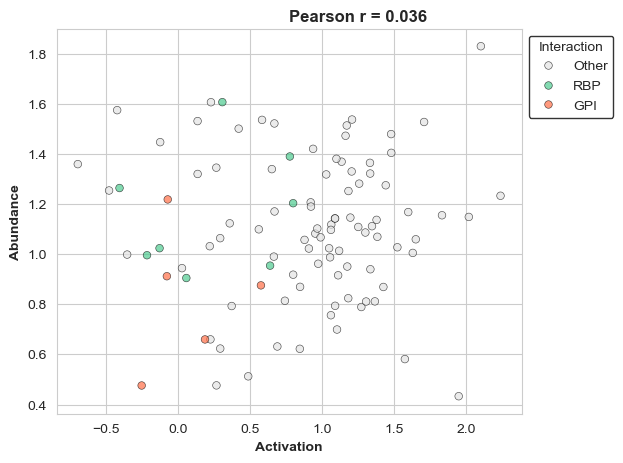

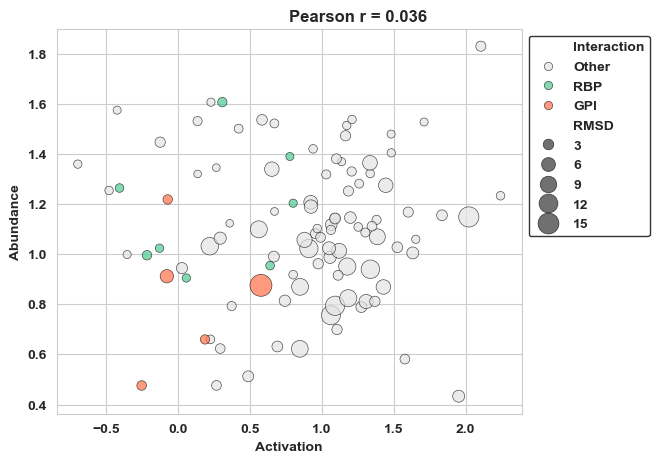

In [19]:
# Abundance vs Activation
abundance_activation_interaction_fig = create_scatter(data_df, condition_x="Activation", condition_y="Abundance",
                                                      sites=True, log_x=False, log_y=False,colour_by="Interaction")

abundance_activation_interaction_RMSD_fig = create_scatter(data_df, condition_x="Activation", condition_y="Abundance",
                                                      sites=True, log_x=False, log_y=False,colour_by="Interaction",
                                                      size_by="RMSD")

output_dir = create_dir(output_root_dir, "Figure3")
abundance_activation_interaction_fig.savefig(os.path.join(output_dir, f"abundance_vs_activation_interaction.svg"))
abundance_activation_interaction_RMSD_fig.savefig(os.path.join(output_dir, f"abundance_vs_activation_domain.svg"))

del abundance_activation_interaction_fig, abundance_activation_interaction_RMSD_fig

In [20]:
activation_df = data_df[["Variant", "Position", "Activation", "variant_type"]].copy()
abundance_df = data_df[["Variant", "Position", "Abundance", "variant_type"]].copy()
light_df = data_df[["Variant", "Position", "Light", "variant_type"]].copy()
dark_df = data_df[["Variant", "Position", "Dark", "variant_type"]].copy()

activation_df = activation_df[activation_df["variant_type"] != "Nonsense"].dropna()
abundance_df = abundance_df[abundance_df["variant_type"] != "Nonsense"].dropna()
light_df = light_df[light_df["variant_type"] != "Nonsense"].dropna()
dark_df = dark_df[dark_df["variant_type"] != "Nonsense"].dropna()

activation_df["Position"] = activation_df["Position"].astype(int)
abundance_df["Position"] = abundance_df["Position"].astype(int)
light_df["Position"] = light_df["Position"].astype(int)
dark_df["Position"] = dark_df["Position"].astype(int)


activation_sites = activation_df.groupby(["Position"])[["Activation"]].median().reset_index()
abundance_sites = abundance_df.groupby(["Position"])[["Abundance"]].median().reset_index()
light_sites = light_df.groupby(["Position"])[["Light"]].median().reset_index()
dark_sites = dark_df.groupby(["Position"])[["Dark"]].median().reset_index()

activation_sites.to_csv(os.path.join(output_root_dir, "activation_median.csv"), index=False)
abundance_sites.to_csv(os.path.join(output_root_dir, "abundance_median.csv"), index=False)
light_sites.to_csv(os.path.join(output_root_dir, "light_median.csv"), index=False)
dark_sites.to_csv(os.path.join(output_root_dir, "dark_median.csv"), index=False)

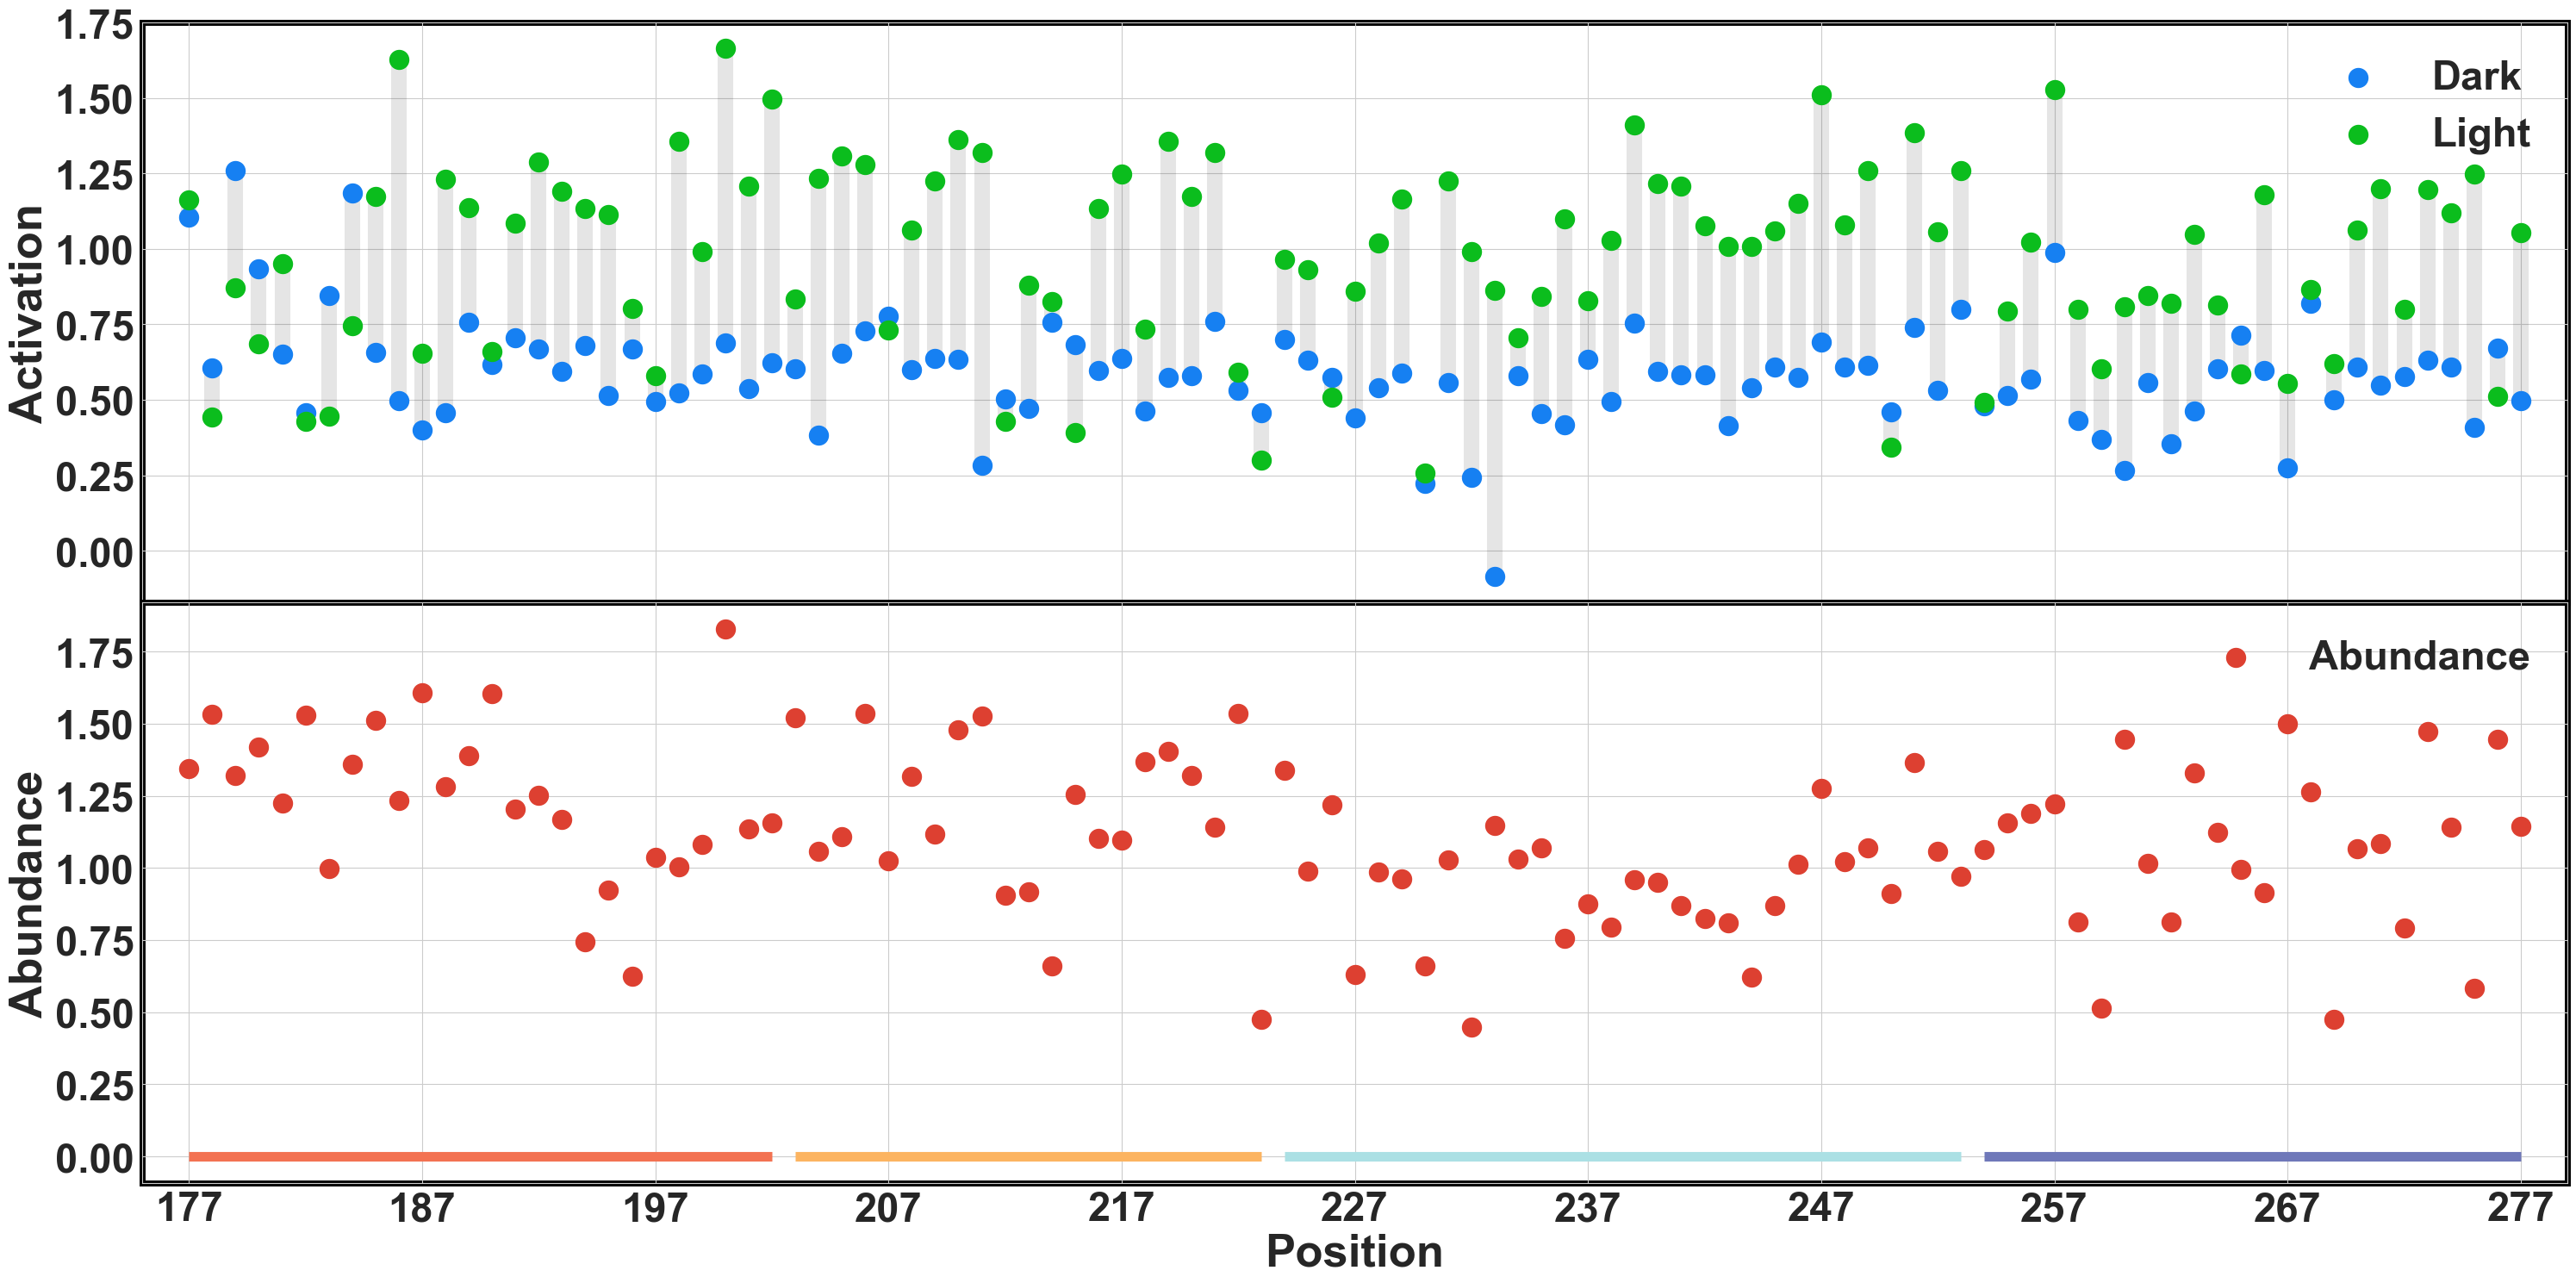

In [21]:
  # lollipop plot for dark and light
df1 = data_df[["Variant", "Position", "Dark", "Light", "Domain", "variant_type"]].copy()
df1 = df1[df1["variant_type"] != "Nonsense"].dropna()
df1["Position"] = df1["Position"].astype(int)
df1_sites = df1.groupby(["Position"])[["Dark", "Light"]].median().reset_index()
df1 = df1_sites.merge(df1[["Position", "Domain"]].drop_duplicates(), on="Position", how="left")
df1 = df1.sort_values(by=["Position"])
del df1_sites

df2 = data_df[["Variant", "Position", "Abundance", "Domain", "variant_type"]].copy()
df2 = df2[df2["variant_type"] != "Nonsense"].dropna()
df2["Position"] = df2["Position"].astype(int)
df2_sites = df2.groupby(["Position"])[["Abundance"]].median().reset_index()
df2 = df2_sites.merge(df2[["Position", "Domain"]].drop_duplicates(), on="Position", how="left")
df2 = df2.sort_values(by=["Position"])
del df2_sites

df3 = data_df[["Variant", "Position", "Activation", "Domain", "variant_type"]].copy()
df3 = df3[df3["variant_type"] != "Nonsense"].dropna()
df3["Position"] = df3["Position"].astype(int)
df3_sites = df3.groupby(["Position"])[["Activation"]].median().reset_index()
df3 = df3_sites.merge(df3[["Position", "Domain"]].drop_duplicates(), on="Position", how="left")
df3 = df3.sort_values(by=["Position"])
del df3_sites

plt.subplots(figsize=(30, 15), nrows=2, ncols=1, sharex=True)
plt.rcParams["svg.fonttype"] = "none"

ax1 = plt.subplot(211)
plt.vlines(x=df1["Position"], ymin=df1["Dark"], ymax=df1["Light"], color="black", alpha=0.1, zorder=1, linewidth=13)

plt.scatter(df1["Position"], df1["Dark"], color="#1680F2", label="Dark", s=250)
plt.scatter(df1["Position"], df1["Light"], color="#0bbd1d", label="Light", s=250)

plt.yticks(fontsize=34, fontname="Arial")
plt.ylabel("Activation", fontsize=38, weight="bold", fontname="Arial")
ax1.legend(frameon=False, fontsize=34)
ax1.patch.set(lw=5, ec="black")


ax2 = plt.subplot(212)
plt.scatter(df2["Position"], df2["Abundance"], color="#DD4031", label="Abundance", s=250)

plt.hlines(y=0, xmin=df2[df2["Domain"] == "ECL2"]["Position"].min(), xmax=df2[df2["Domain"] == "ECL2"]["Position"].max(), color="#f37252", linewidth=8)
plt.hlines(y=0, xmin=df2[df2["Domain"] == "TM5"]["Position"].min(), xmax=df2[df2["Domain"] == "TM5"]["Position"].max(), color="#fcb461", linewidth=8)
plt.hlines(y=0, xmin=df2[df2["Domain"] == "ICL3"]["Position"].min(), xmax=df2[df2["Domain"] == "ICL3"]["Position"].max(), color="#abe0e4", linewidth=8)
plt.hlines(y=0, xmin=df2[df2["Domain"] == "TM6"]["Position"].min(), xmax=df2[df2["Domain"] == "TM6"]["Position"].max(), color="#6f78b9", linewidth=8)
ax2.set_xticks([i for i in range(df2["Position"].min(), df2["Position"].max() + 1, 10)])
ax2.patch.set(lw=5, ec="black")

plt.xticks(fontsize=34, fontname="Arial")
plt.yticks(fontsize=34, fontname="Arial")
plt.xlabel("Position", fontsize=38, weight="bold", fontname="Arial")
plt.ylabel("Abundance", fontsize=38, weight="bold", fontname="Arial")

plt.xlim(175,279)
ax2.legend(frameon=False, fontsize=34)

plt.tight_layout()
plt.subplots_adjust(hspace=0)

output_dir = create_dir(output_root_dir, "Figure3")
plt.savefig(os.path.join(output_dir, "Dark_Light_Abundance_Dotplot.svg"))


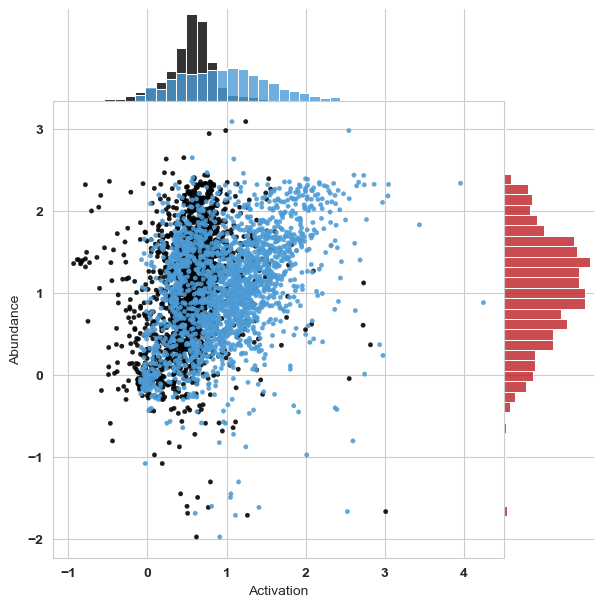

In [22]:
# Overlay scatterplot of Dark and Light, with adjunct histogram. Colored by variant_type

df = data_df[["Variant", "variant_type", "Dark", "Light", "Abundance"]].copy().dropna()


df_dark = df[["Variant", "variant_type", "Dark", "Abundance"]].copy()
df_dark.rename(columns={"Dark": "Activation"}, inplace=True)
df_dark["activation_type"] = "Dark"
df_light = df[["Variant", "variant_type", "Light", "Abundance"]].copy()
df_light = df_light[df_light["Light"] >= -0.1]
df_light.rename(columns={"Light": "Activation"}, inplace=True)
df_light["activation_type"] = "Light"

df_all = pd.concat([df_dark, df_light])
del df_dark, df_light

fig = sns.JointGrid(space=0)
plt.rcParams["svg.fonttype"] = "none"
x, y = df_all["Activation"], df_all["Abundance"]

activation_type_palette = {
    "Dark": "black",
    "Light": "#4c9bd5",
}

sns.scatterplot(
    x=x,
    y=y,
    hue=df_all["activation_type"],
    palette=activation_type_palette,
    hue_order=["Light", "Dark"],
    edgecolor=None,
    alpha=0.89,
    s=10,
    legend=False,
    ax=fig.ax_joint
)

sns.histplot(
    x=x,
    hue=df_all["activation_type"],
    palette=activation_type_palette,
    alpha=0.8,
    hue_order=["Light", "Dark"],
    bins=40,
    legend=False,
    ax=fig.ax_marg_x,
)

sns.histplot(
    y=y,
    color="#bd1e24",
    alpha=0.8,
    bins=40,
    ax=fig.ax_marg_y
)

output_dir = create_dir(output_root_dir, "Talk")
fig.savefig(os.path.join(output_dir, "JointPlot.svg"))

del df, df_all, x, y, activation_type_palette, fig, output_dir


## Summary Statistics

Total number of variants: 1917
Number of variants with both activation and abundance higher than WT: 167
Number of variants with both activation and abundance lower than WT: 70
Number of variants with increased activation and decreased abundance: 21
Number of variants with decreased activation and increased abundance: 76
Number of neutral variants: 801


<Axes: xlabel='Activation', ylabel='Abundance'>

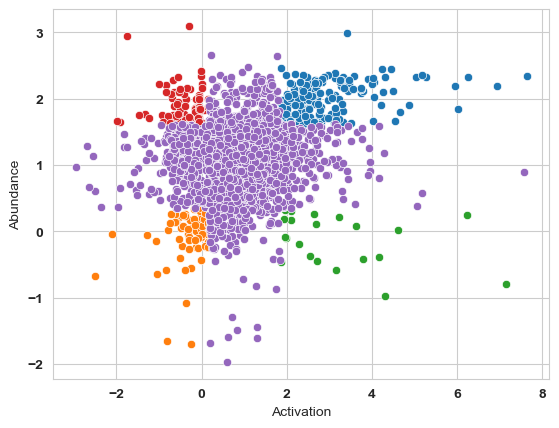

In [23]:
# Get Synonymous variants median for activation and abundance
activation_threshold = data_df[data_df["variant_type"] == "Synonymous"]["Activation"].median()
activation_sd = data_df[data_df["variant_type"] == "Synonymous"]["Activation"].std()

abundance_threshold = data_df[data_df["variant_type"] == "Synonymous"]["Abundance"].median()
abundance_sd = data_df[data_df["variant_type"] == "Synonymous"]["Abundance"].std()

activation_upper = activation_threshold + activation_sd
activation_lower = activation_threshold - activation_sd

abundance_upper = abundance_threshold + abundance_sd
abundance_lower = abundance_threshold - abundance_sd

# Remove Nonsense variants from data_df and only keep Activation and Abundance
data_df_clean = data_df[data_df["variant_type"] != "Nonsense"][["Variant", "Activation", "Abundance"]].dropna()

# Get gain of function, loss of function, and neutral variants
activation_gof = data_df_clean[data_df_clean["Activation"] > activation_upper][["Variant", "Activation"]]
activation_lof = data_df_clean[data_df_clean["Activation"] < activation_lower][["Variant", "Activation"]]
activation_neutral = data_df_clean[(data_df_clean["Activation"] >= activation_lower) &
                                   (data_df_clean["Activation"] <= activation_upper)][["Variant", "Activation"]]

abundance_gof = data_df_clean[data_df_clean["Abundance"] > abundance_upper][["Variant", "Abundance"]]
abundance_lof = data_df_clean[data_df_clean["Abundance"] < abundance_lower][["Variant", "Abundance"]]
abundance_neutral = data_df_clean[(data_df_clean["Abundance"] >= abundance_lower) &
                                  (data_df_clean["Abundance"] <= abundance_upper)][["Variant", "Abundance"]]


print(f"Total number of variants: {len(data_df_clean)}")

double_gof = activation_gof.merge(abundance_gof, on=["Variant"], how="inner")
print(f"Number of variants with both activation and abundance higher than WT: {len(double_gof)}")

double_lof = activation_lof.merge(abundance_lof, on=["Variant"], how="inner")
print(f"Number of variants with both activation and abundance lower than WT: {len(double_lof)}")

activation_gof_abundance_lof = activation_gof.merge(abundance_lof, on=["Variant"], how="inner")
print(f"Number of variants with increased activation and decreased abundance: {len(activation_gof_abundance_lof)}")

activation_lof_abundance_gof = activation_lof.merge(abundance_gof, on=["Variant"], how="inner")
print(f"Number of variants with decreased activation and increased abundance: {len(activation_lof_abundance_gof)}")

neutral = activation_neutral.merge(abundance_neutral, on=["Variant"], how="inner")
neutral_all = activation_neutral["Variant"].to_frame().merge(abundance_neutral["Variant"].to_frame(), on=["Variant"], how="outer").merge(data_df_clean, on=["Variant"], how="inner")
print(f"Number of neutral variants: {len(neutral)}")


# Plot
sns.scatterplot(
    double_gof,
    x="Activation",
    y="Abundance",
)

sns.scatterplot(
    double_lof,
    x="Activation",
    y="Abundance",
)

sns.scatterplot(
    activation_gof_abundance_lof,
    x="Activation",
    y="Abundance",
)

sns.scatterplot(
    activation_lof_abundance_gof,
    x="Activation",
    y="Abundance",
)

sns.scatterplot(
    neutral_all,
    x="Activation",
    y="Abundance",
)



# del activation_threshold, activation_sd, abundance_threshold, abundance_sd, activation_upper, activation_lower, abundance_upper, abundance_lower, data_df_clean, activation_gof, activation_lof, activation_neutral, abundance_gof, abundance_lof, abundance_neutral, double_gof, double_lof, activation_gof_abundance_lof, activation_lof_abundance_gof, neutral

Total number of variants: 1917
Number of variants with both activation and abundance higher than WT: 434
Number of variants with both activation and abundance lower than WT: 16
Number of variants with increased activation and decreased abundance: 15
Number of variants with decreased activation and increased abundance: 204
Number of neutral variants: 400


<Axes: xlabel='Activation', ylabel='Abundance'>

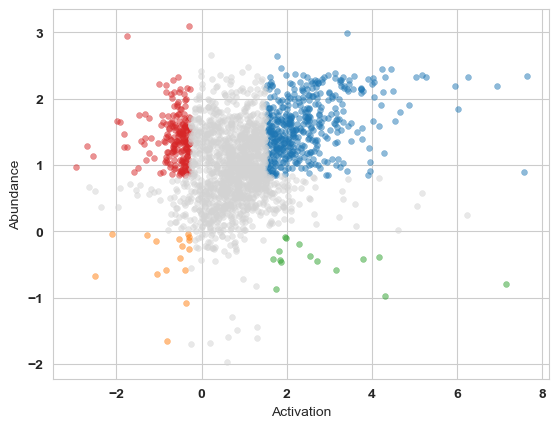

In [24]:
# Get Synonymous variants median for activation and abundance


activation_upper = data_df[data_df["variant_type"] == "Nonsense"]["Activation"].quantile(0.95)
activation_lower = data_df[data_df["variant_type"] == "Synonymous"]["Activation"].quantile(0.05)

abundance_upper = data_df[data_df["variant_type"] == "Nonsense"]["Abundance"].quantile(0.95)
abundance_lower = data_df[data_df["variant_type"] == "Synonymous"]["Abundance"].quantile(0.05)

# Remove Nonsense variants from data_df and only keep Activation and Abundance
data_df_clean = data_df[data_df["variant_type"] != "Nonsense"][["Variant", "Activation", "Abundance"]].dropna()

# Get gain of function, loss of function, and neutral variants
activation_gof = data_df_clean[data_df_clean["Activation"] > activation_upper][["Variant", "Activation"]]
activation_lof = data_df_clean[data_df_clean["Activation"] < activation_lower][["Variant", "Activation"]]
activation_neutral = data_df_clean[(data_df_clean["Activation"] >= activation_lower) &
                                   (data_df_clean["Activation"] <= activation_upper)][["Variant", "Activation"]]

abundance_gof = data_df_clean[data_df_clean["Abundance"] > abundance_upper][["Variant", "Abundance"]]
abundance_lof = data_df_clean[data_df_clean["Abundance"] < abundance_lower][["Variant", "Abundance"]]
abundance_neutral = data_df_clean[(data_df_clean["Abundance"] >= abundance_lower) &
                                  (data_df_clean["Abundance"] <= abundance_upper)][["Variant", "Abundance"]]


print(f"Total number of variants: {len(data_df_clean)}")

double_gof = activation_gof.merge(abundance_gof, on=["Variant"], how="inner")
print(f"Number of variants with both activation and abundance higher than WT: {len(double_gof)}")

double_lof = activation_lof.merge(abundance_lof, on=["Variant"], how="inner")
print(f"Number of variants with both activation and abundance lower than WT: {len(double_lof)}")

activation_gof_abundance_lof = activation_gof.merge(abundance_lof, on=["Variant"], how="inner")
print(f"Number of variants with increased activation and decreased abundance: {len(activation_gof_abundance_lof)}")

activation_lof_abundance_gof = activation_lof.merge(abundance_gof, on=["Variant"], how="inner")
print(f"Number of variants with decreased activation and increased abundance: {len(activation_lof_abundance_gof)}")

neutral = activation_neutral.merge(abundance_neutral, on=["Variant"], how="inner")
neutral_all = activation_neutral["Variant"].to_frame().merge(abundance_neutral["Variant"].to_frame(), on=["Variant"], how="outer").merge(data_df_clean, on=["Variant"], how="inner")
print(f"Number of neutral variants: {len(neutral)}")


# Plot
sns.scatterplot(
    double_gof,
    x="Activation",
    y="Abundance",
    edgecolor=None,
    alpha=0.5,
    s=18,
)

sns.scatterplot(
    double_lof,
    x="Activation",
    y="Abundance",
    edgecolor=None,
    alpha=0.5,
    s=18,
)

sns.scatterplot(
    activation_gof_abundance_lof,
    x="Activation",
    y="Abundance",
    edgecolor=None,
    alpha=0.5,
    s=18,
)

sns.scatterplot(
    activation_lof_abundance_gof,
    x="Activation",
    y="Abundance",
    edgecolor=None,
    alpha=0.5,
    s=18,
)

sns.scatterplot(
    neutral_all,
    x="Activation",
    y="Abundance",
    edgecolor=None,
    alpha=0.5,
    s=18,
    color="lightgrey"

)


# del activation_threshold, activation_sd, abundance_threshold, abundance_sd, activation_upper, activation_lower, abundance_upper, abundance_lower, data_df_clean, activation_gof, activation_lof, activation_neutral, abundance_gof, abundance_lof, abundance_neutral, double_gof, double_lof, activation_gof_abundance_lof, activation_lof_abundance_gof, neutral

In [25]:
# Get Synonymous variants median for activation and abundance
activation_threshold = data_df[data_df["variant_type"] == "Synonymous"]["Activation"].median()
# activation_sd = data_df[data_df["variant_type"] == "Synonymous"]["Activation"].std()

abundance_threshold = data_df[data_df["variant_type"] == "Synonymous"]["Abundance"].median()
# abundance_sd = data_df[data_df["variant_type"] == "Synonymous"]["Abundance"].std()

activation_upper = data_df[data_df["variant_type"] == "Synonymous"]["Activation"].quantile(0.975)
activation_lower = data_df[data_df["variant_type"] == "Synonymous"]["Activation"].quantile(0.025)

abundance_upper = data_df[data_df["variant_type"] == "Synonymous"]["Abundance"].quantile(0.975)
abundance_lower = data_df[data_df["variant_type"] == "Synonymous"]["Abundance"].quantile(0.025)

# Remove Nonsense variants from data_df and only keep Activation and Abundance
data_df_clean = data_df[data_df["variant_type"] != "Nonsense"][["Variant", "Activation", "Abundance"]].dropna()

# Get gain of function, loss of function, and neutral variants
activation_gof = data_df_clean[data_df_clean["Activation"] > activation_upper][["Variant", "Activation"]]
activation_lof = data_df_clean[data_df_clean["Activation"] < activation_lower][["Variant", "Activation"]]
activation_neutral = data_df_clean[(data_df_clean["Activation"] >= activation_lower) &
                                   (data_df_clean["Activation"] <= activation_upper)][["Variant", "Activation"]]

abundance_gof = data_df_clean[data_df_clean["Abundance"] > abundance_upper][["Variant", "Abundance"]]
abundance_lof = data_df_clean[data_df_clean["Abundance"] < abundance_lower][["Variant", "Abundance"]]
abundance_neutral = data_df_clean[(data_df_clean["Abundance"] >= abundance_lower) &
                                  (data_df_clean["Abundance"] <= abundance_upper)][["Variant", "Abundance"]]

print(f"Total number of variants: {len(data_df_clean)}")

double_gof = activation_gof.merge(abundance_gof, on=["Variant"], how="inner")
print(f"Number of variants with both activation and abundance higher than WT: {len(double_gof)}")

double_lof = activation_lof.merge(abundance_lof, on=["Variant"], how="inner")
print(f"Number of variants with both activation and abundance lower than WT: {len(double_lof)}")

activation_gof_abundance_lof = activation_gof.merge(abundance_lof, on=["Variant"], how="inner")
print(f"Number of variants with increased activation and decreased abundance: {len(activation_gof_abundance_lof)}")

activation_lof_abundance_gof = activation_lof.merge(abundance_gof, on=["Variant"], how="inner")
print(f"Number of variants with decreased activation and increased abundance: {len(activation_lof_abundance_gof)}")

neutral = activation_neutral.merge(abundance_neutral, on=["Variant"], how="inner")
print(f"Number of neutral variants: {len(neutral)}")

del activation_threshold, abundance_threshold, activation_upper, activation_lower, abundance_upper, abundance_lower, data_df_clean, activation_gof, activation_lof, activation_neutral, abundance_gof, abundance_lof, abundance_neutral, double_gof, double_lof, activation_gof_abundance_lof, activation_lof_abundance_gof, neutral

Total number of variants: 1917
Number of variants with both activation and abundance higher than WT: 57
Number of variants with both activation and abundance lower than WT: 4
Number of variants with increased activation and decreased abundance: 3
Number of variants with decreased activation and increased abundance: 10
Number of neutral variants: 1479


## Number of activatable variants

In [26]:
activation_df = data_df["Activation"].dropna()
print(f"Total number of variants: {len(activation_df)}")
print(f"Total number of activatable variants: {len(activation_df[activation_df > 0])}")
print(f"Total number of non-activatable variants: {len(activation_df[activation_df <= 0])}")
del activation_df

Total number of variants: 2019
Total number of activatable variants: 1582
Total number of non-activatable variants: 437


## RBP and GPI variant scores

In [27]:
Interaction_df = data_df[data_df['variant_type'] != 'Nonsense'][['Variant', 'Activation', 'Abundance', 'Interaction']].copy()
Interaction_df['Site'] = Interaction_df['Variant'].str[:-1]
Interaction_df['AA'] = Interaction_df['Variant'].str[-1]
RBP_df = Interaction_df[Interaction_df['Interaction'] == 'RBP']
GPI_df = Interaction_df[Interaction_df['Interaction'] == 'GPI']

<Axes: xlabel='AA', ylabel='Site'>

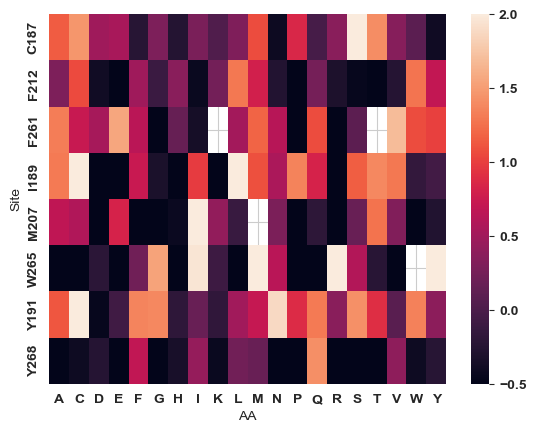

In [28]:
sns.heatmap(
    RBP_df.pivot(
        index='Site',
        columns='AA',
        values='Activation'
    ),
    vmin=-0.5,
    vmax=2
)

<Axes: xlabel='AA', ylabel='Site'>

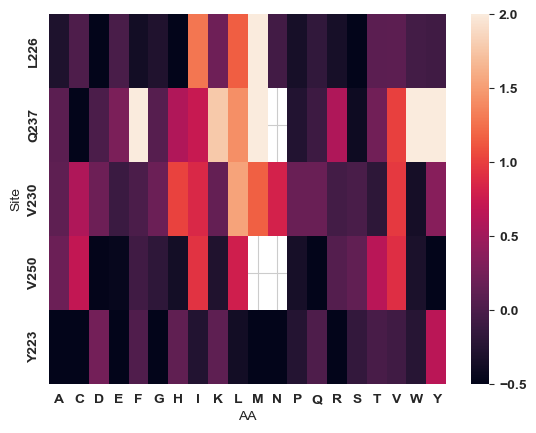

In [29]:
sns.heatmap(
    GPI_df.pivot(
        index='Site',
        columns='AA',
        values='Activation'
    ),
    vmin=-0.5,
    vmax=2
)

<Axes: xlabel='AA', ylabel='Site'>

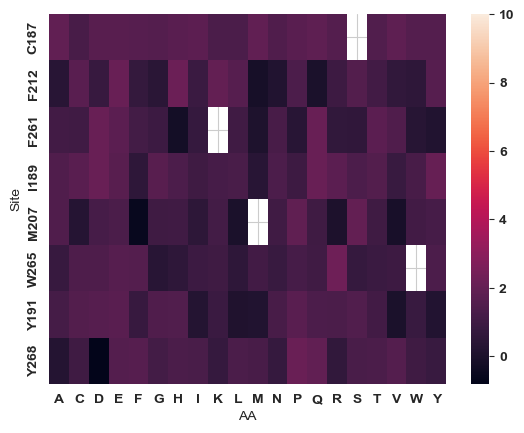

In [30]:
sns.heatmap(
    RBP_df.pivot(
        index='Site',
        columns='AA',
        values='Abundance'
    ),
    vmin=-0.8,
    vmax=10
)

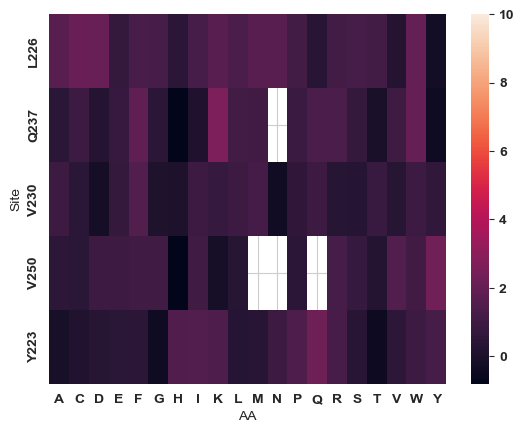

In [31]:
sns.heatmap(
    GPI_df.pivot(
        index='Site',
        columns='AA',
        values='Abundance'
    ),
    vmin=-0.8,
    vmax=10
)

del Interaction_df, RBP_df, GPI_df

## Amino acids

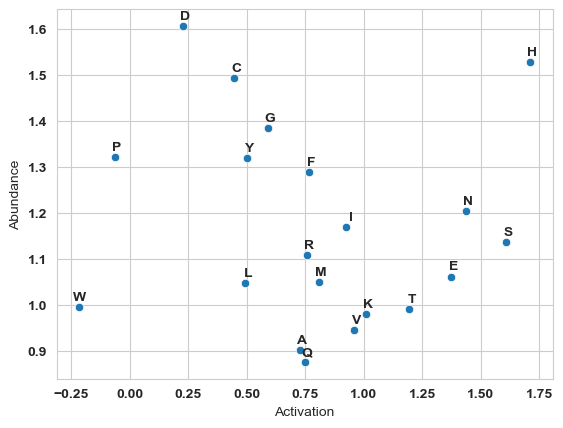

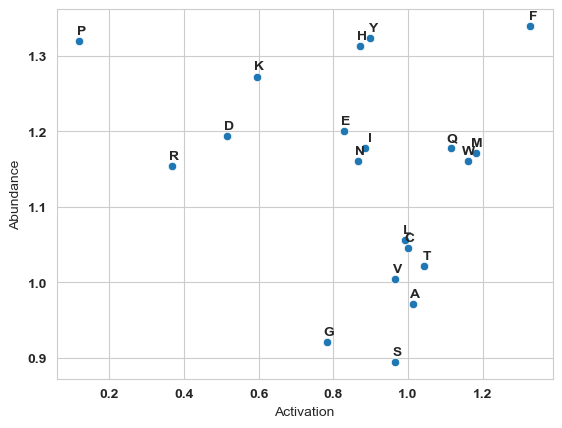

In [32]:
AA_df = data_df[data_df['variant_type'] != 'Nonsense'][['Variant', 'Activation', 'Abundance']].copy()
AA_df['WT_AA'] = AA_df['Variant'].str[0]
AA_df['Position'] = AA_df['Variant'].str[:-1]
AA_df['MUT_AA'] = AA_df['Variant'].str[-1]

# Group by WT_AA and calculate median
WT_activation = AA_df.groupby(by=['WT_AA'])['Activation'].median().reset_index()
WT_abundance = AA_df.groupby(by=['WT_AA'])['Abundance'].median().reset_index()
WT_df = WT_activation.merge(WT_abundance, on=['WT_AA'])
del WT_activation, WT_abundance

# Group by MUT_AA and calculate median
MUT_activation = AA_df.groupby(by=['MUT_AA'])['Activation'].median().reset_index()
MUT_abundance = AA_df.groupby(by=['MUT_AA'])['Abundance'].median().reset_index()
MUT_df = MUT_activation.merge(MUT_abundance, on=['MUT_AA'])
del MUT_activation, MUT_abundance

# Create scatter plot for WT and MUT (abundance vs activation)
fig, ax = plt.subplots()

sns.scatterplot(
    data=WT_df,
    x="Activation",
    y="Abundance",
    ax=ax
)

for _, row in WT_df.iterrows():
    ax.annotate(
        row["WT_AA"],
        xy=(row["Activation"], row["Abundance"]),
        xytext=(5, 5),
        textcoords="offset points",
        ha="right",
    )

plt.show()

fig, ax = plt.subplots()

sns.scatterplot(
    data=MUT_df,
    x="Activation",
    y="Abundance",
    ax=ax
)

for _, row in MUT_df.iterrows():
    ax.annotate(
        row["MUT_AA"],
        xy=(row["Activation"], row["Abundance"]),
        xytext=(5, 5),
        textcoords="offset points",
        ha="right",
    )

del AA_df, MUT_df, WT_df, fig, ax, row

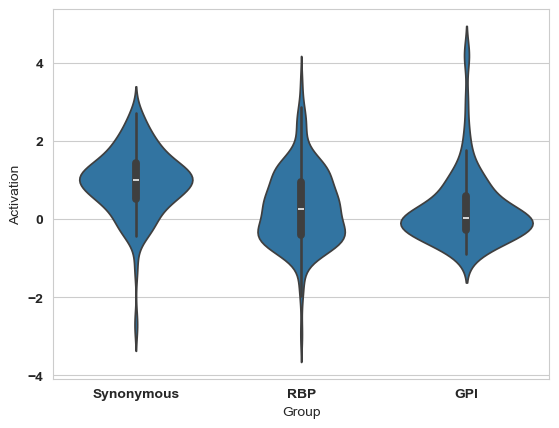

<Axes: xlabel='Group', ylabel='Abundance'>

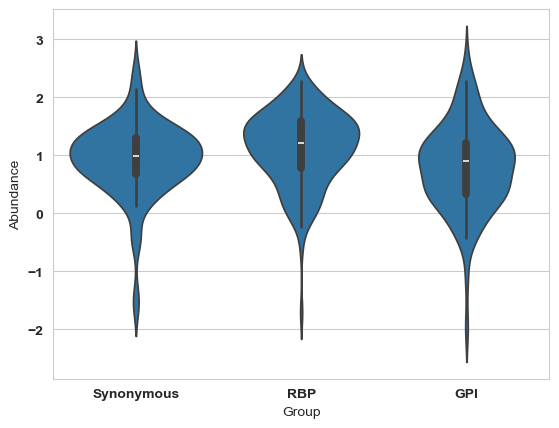

In [33]:
df = data_df[['Position', 'Interaction', 'Activation', 'Abundance', 'variant_type']].copy().dropna()
df = df[df['variant_type'] != 'Nonsense']
# df = df.groupby(['Position', 'Interaction']).median().reset_index()
syn = df[df['variant_type'] == 'Synonymous'][['Activation', 'Abundance']].assign(Group='Synonymous')
RBP = df[df['Interaction'] == 'RBP'][['Activation', 'Abundance']].assign(Group='RBP')
GPI = df[df['Interaction'] == 'GPI'][['Activation', 'Abundance']].assign(Group='GPI')

activation_df = pd.concat([syn[['Activation', 'Group']], RBP[['Activation', 'Group']], GPI[['Activation', 'Group']]])

abundance_df = pd.concat([syn[['Abundance', 'Group']], RBP[['Abundance', 'Group']], GPI[['Abundance', 'Group']]])

sns.violinplot(
    data=activation_df,
    x='Group',
    y='Activation',
)

plt.show()
sns.violinplot(
    data=abundance_df,
    x='Group',
    y='Abundance',
)



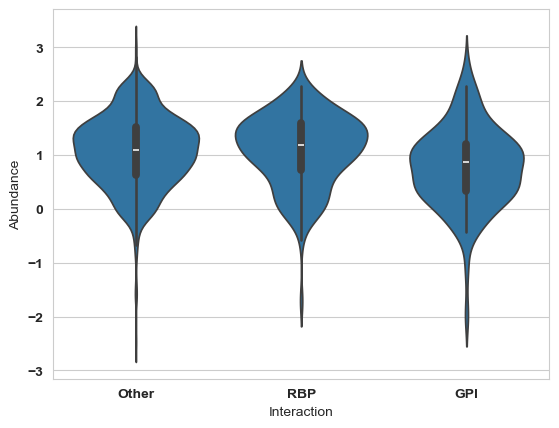

In [34]:

df = data_df[['Position', 'Interaction', 'Abundance']].copy()
# df = df.groupby(['Position', 'Interaction']).median().reset_index()

sns.violinplot(
    data=df,
    x='Interaction',
    y='Abundance',
)

del df

In [35]:
# Calculate mutational tolerance
synonymous_activation_median = data_df[data_df["variant_type"] == "Synonymous"]["Activation"].median()
synonymous_abundance_median = data_df[data_df["variant_type"] == "Synonymous"]["Abundance"].median()

data_df = cal_mutational_tolerance(data_df, synonymous_activation_median, "Activation")
data_df = cal_mutational_tolerance(data_df, synonymous_abundance_median, "Abundance")


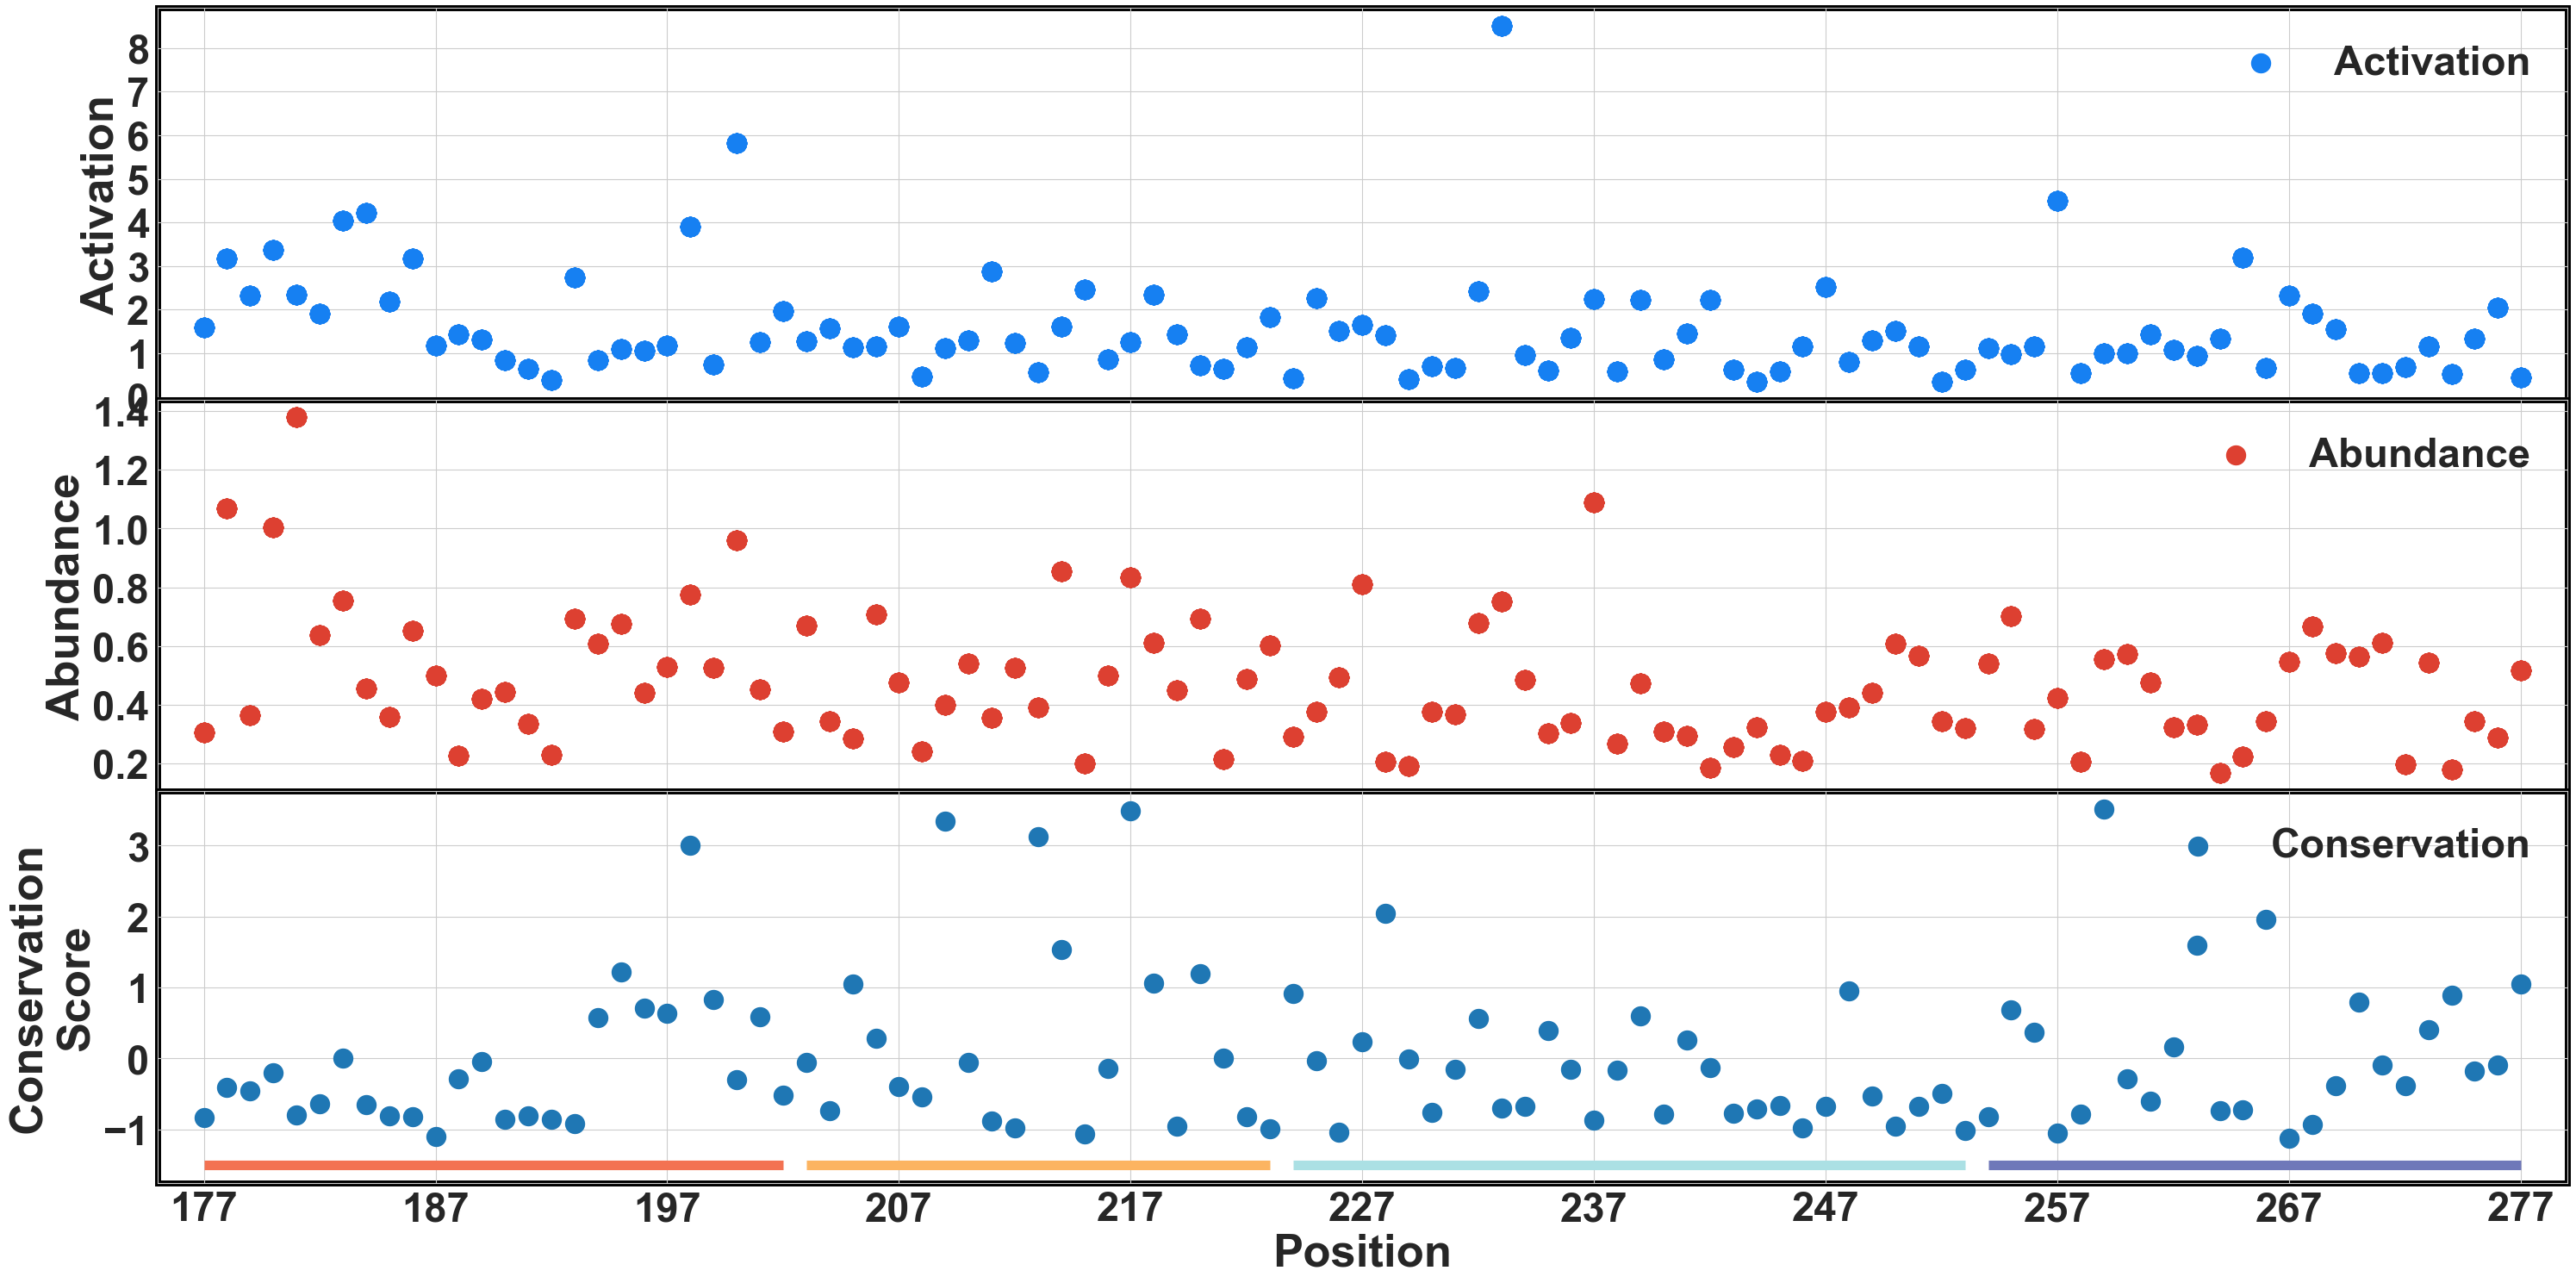

In [36]:
df1 = data_df[["Variant", "Position", "Mutational_Tolerance_Activation", "Domain"]].copy()
df1 = df1[df1["Variant"] != "Nonsense"].dropna()
df1 = df1.sort_values(by=["Position"])

df2 = data_df[["Variant", "Position", "Mutational_Tolerance_Abundance", "Domain"]].copy()
df2 = df2[df2["Variant"] != "Nonsense"].dropna()
df2 = df2.sort_values(by=["Position"])

df3 = data_df[["Position", "Conservation_score"]].copy()
df3 = df3.groupby(["Position"])[["Conservation_score"]].median().reset_index()


plt.subplots(figsize=(30, 15), nrows=3, ncols=1, sharex=True)
plt.rcParams["svg.fonttype"] = "none"

ax1 = plt.subplot(311)
plt.scatter(df1["Position"], df1["Mutational_Tolerance_Activation"], color="#1680F2", label="Activation", s=250)

plt.yticks(fontsize=34, fontname="Arial")
plt.ylabel("Activation", fontsize=38, weight="bold", fontname="Arial")
ax1.legend(frameon=False, fontsize=34)
ax1.patch.set(lw=5, ec="black")


ax2 = plt.subplot(312)
plt.scatter(df2["Position"], df2["Mutational_Tolerance_Abundance"], color="#DD4031", label="Abundance", s=250)


ax2.set_xticks([i for i in range(df2["Position"].min(), df2["Position"].max() + 1, 10)])
ax2.patch.set(lw=5, ec="black")

plt.yticks(fontsize=34, fontname="Arial")
plt.ylabel("Abundance", fontsize=38, weight="bold", fontname="Arial")

plt.xlim(175,279)
ax2.legend(frameon=False, fontsize=34)



ax3 = plt.subplot(313)
plt.scatter(df3["Position"], df3["Conservation_score"], label="Conservation", s=250)

plt.hlines(y=-1.5, xmin=df2[df2["Domain"] == "ECL2"]["Position"].min(), xmax=df2[df2["Domain"] == "ECL2"]["Position"]
           .max(), color="#f37252", linewidth=8)
plt.hlines(y=-1.5, xmin=df2[df2["Domain"] == "TM5"]["Position"].min(), xmax=df2[df2["Domain"] == "TM5"]["Position"].max(), color="#fcb461", linewidth=8)
plt.hlines(y=-1.5, xmin=df2[df2["Domain"] == "ICL3"]["Position"].min(), xmax=df2[df2["Domain"] == "ICL3"]["Position"].max(), color="#abe0e4", linewidth=8)
plt.hlines(y=-1.5, xmin=df2[df2["Domain"] == "TM6"]["Position"].min(), xmax=df2[df2["Domain"] == "TM6"]["Position"].max(), color="#6f78b9", linewidth=8)

ax3.patch.set(lw=5, ec="black")
ax3.legend(frameon=False, fontsize=34)

plt.xticks(fontsize=34, fontname="Arial")
plt.yticks(fontsize=34, fontname="Arial")
plt.xlabel("Position", fontsize=38, weight="bold", fontname="Arial")
plt.ylabel("Conservation\nScore", fontsize=38, weight="bold", fontname="Arial")

plt.tight_layout()
plt.subplots_adjust(hspace=0)

del df1, df2, df3, ax1, ax2, ax3

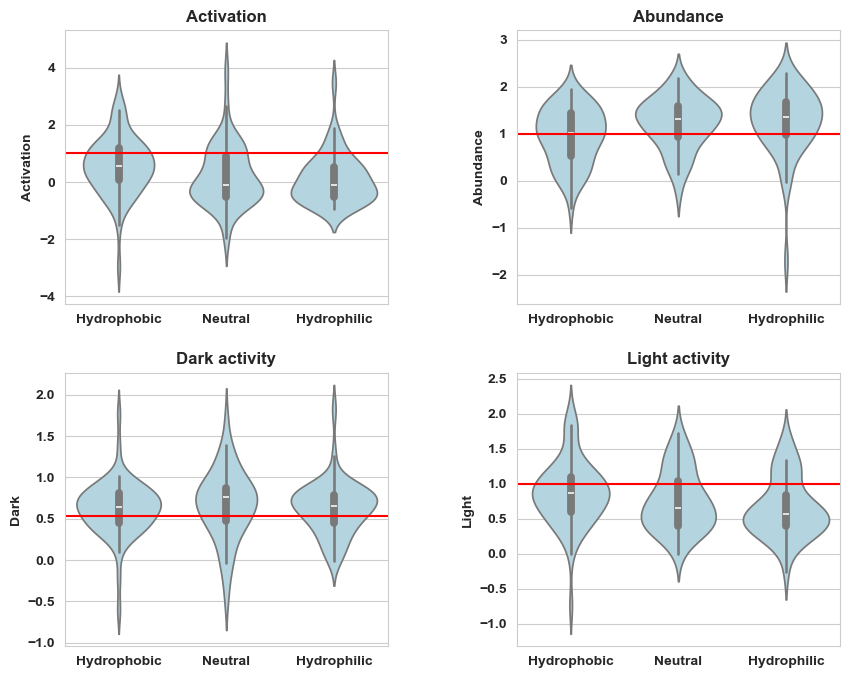

In [37]:
# Property scatter plot
variants_df = data_df.copy()
variants_df = variants_df[['Variant', 'Position', 'variant_type', 'Domain', 'Interaction', 'Dark', 'Light', 'Activation', 'Abundance']]
variants_df['AA'] = variants_df['Variant'].str[-1]
variants_df = variants_df[variants_df['variant_type'] != 'Nonsense']

aa_properties = {
    'A': 'Hydrophobic',
    'C': 'Hydrophobic',
    'I': 'Hydrophobic',
    'L': 'Hydrophobic',
    'M': 'Hydrophobic',
    'F': 'Hydrophobic',
    'W': 'Hydrophobic',
    'V': 'Hydrophobic',
    'G': 'Neutral',
    'H': 'Neutral',
    'P': 'Neutral',
    'S': 'Neutral',
    'T': 'Neutral',
    'Y': 'Neutral',
    'R': 'Hydrophilic',
    'N': 'Hydrophilic',
    'D': 'Hydrophilic',
    'Q': 'Hydrophilic',
    'E': 'Hydrophilic',
    'K': 'Hydrophilic'
}

variants_df['Property'] = variants_df['AA'].map(aa_properties)



# sns.scatterplot(
#     data=variants_df[(variants_df['Interaction'] == 'RBP') & (variants_df['variant_type'] == 'Missense')],
#     x='Activation',
#     y='Abundance',
#     hue='Property',
#     edgecolor=None,
#     alpha=0.6,
#     s=40
# )

# sns.scatterplot(
#     data=variants_df[(variants_df['Interaction'] == 'RBP') & (variants_df['variant_type'] == 'Synonymous')],
#     x='Activation',
#     y='Abundance',
#     color='red',
#     edgecolor=None,
#     alpha=0.6,
#     s=40
# )
# plt.legend(bbox_to_anchor=(1, 1.02))
#
# plt.show()

# Filter to RBP variants
rbp_df = variants_df[variants_df['Interaction'] == 'RBP']

# Set up figure with 2×2 layout
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Shared order for consistent x-axis
prop_order = ['Hydrophobic', 'Neutral', 'Hydrophilic']

# ---- Plot 1: Activation ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Activation',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[0],
)
axes[0].axhline(y=1, color='red', linestyle='-', linewidth=1.5)
axes[0].set_title('Activation', fontsize=12, weight='bold')
axes[0].set_ylabel('Activation', fontsize=10, weight='bold')

# ---- Plot 2: Abundance ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Abundance',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[1],
)
axes[1].axhline(y=1, color='red', linestyle='-', linewidth=1.5)
axes[1].set_title('Abundance', fontsize=12, weight='bold')
axes[1].set_ylabel('Abundance', fontsize=10, weight='bold')

# ---- Plot 3: Dark ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Dark',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[2],
)
axes[2].axhline(y=0.53, color='red', linestyle='-', linewidth=1.5)
axes[2].set_title('Dark activity', fontsize=12, weight='bold')
axes[2].set_ylabel('Dark', fontsize=10, weight='bold')

# ---- Plot 4: Light ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Light',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[3],
)
axes[3].axhline(y=1, color='red', linestyle='-', linewidth=1.5)
axes[3].set_title('Light activity', fontsize=12, weight='bold')
axes[3].set_ylabel('Light', fontsize=10, weight='bold')

for ax in axes:
    ax.set_xlabel('')


# Adjust subplot spacing
plt.subplots_adjust(wspace=0.4, hspace=0.25)
plt.show()# hide "Property" label


del variants_df, aa_properties, rbp_df, fig, axes

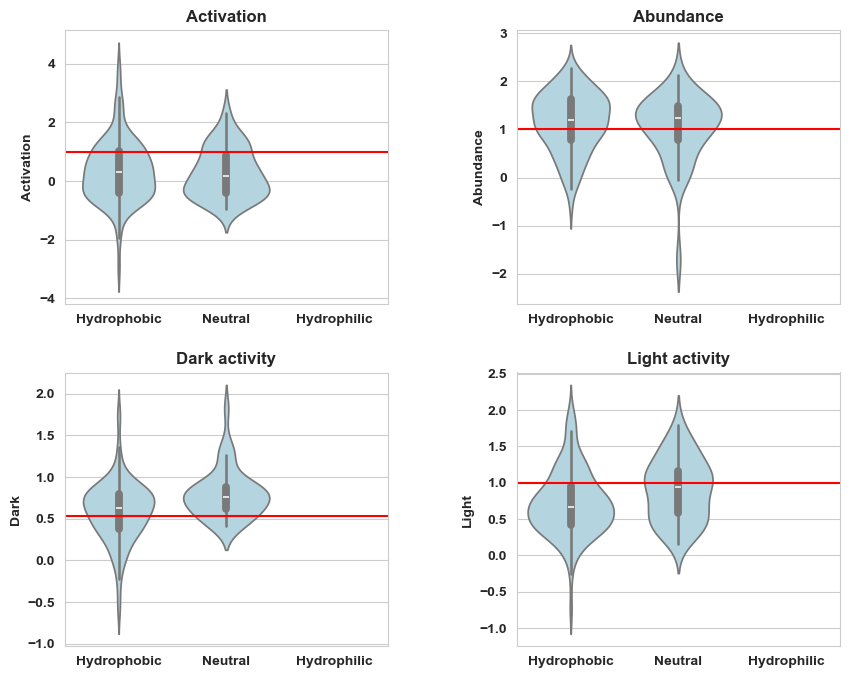

In [38]:
# Property scatter plot
variants_df = data_df.copy()
variants_df = variants_df[['Variant', 'Position', 'variant_type', 'Domain', 'Interaction', 'Dark', 'Light', 'Activation', 'Abundance']]
variants_df['AA'] = variants_df['Variant'].str[0]
variants_df = variants_df[variants_df['variant_type'] != 'Nonsense']

aa_properties = {
    'A': 'Hydrophobic',
    'C': 'Hydrophobic',
    'I': 'Hydrophobic',
    'L': 'Hydrophobic',
    'M': 'Hydrophobic',
    'F': 'Hydrophobic',
    'W': 'Hydrophobic',
    'V': 'Hydrophobic',
    'G': 'Neutral',
    'H': 'Neutral',
    'P': 'Neutral',
    'S': 'Neutral',
    'T': 'Neutral',
    'Y': 'Neutral',
    'R': 'Hydrophilic',
    'N': 'Hydrophilic',
    'D': 'Hydrophilic',
    'Q': 'Hydrophilic',
    'E': 'Hydrophilic',
    'K': 'Hydrophilic'
}

variants_df['Property'] = variants_df['AA'].map(aa_properties)



# sns.scatterplot(
#     data=variants_df[(variants_df['Interaction'] == 'RBP') & (variants_df['variant_type'] == 'Missense')],
#     x='Activation',
#     y='Abundance',
#     hue='Property',
#     edgecolor=None,
#     alpha=0.6,
#     s=40
# )

# sns.scatterplot(
#     data=variants_df[(variants_df['Interaction'] == 'RBP') & (variants_df['variant_type'] == 'Synonymous')],
#     x='Activation',
#     y='Abundance',
#     color='red',
#     edgecolor=None,
#     alpha=0.6,
#     s=40
# )
# plt.legend(bbox_to_anchor=(1, 1.02))
#
# plt.show()

# Filter to RBP variants
rbp_df = variants_df[variants_df['Interaction'] == 'RBP']

# Set up figure with 2×2 layout
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Shared order for consistent x-axis
prop_order = ['Hydrophobic', 'Neutral', 'Hydrophilic']

# ---- Plot 1: Activation ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Activation',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[0],
)
axes[0].axhline(y=1, color='red', linestyle='-', linewidth=1.5)
axes[0].set_title('Activation', fontsize=12, weight='bold')
axes[0].set_ylabel('Activation', fontsize=10, weight='bold')

# ---- Plot 2: Abundance ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Abundance',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[1],
)
axes[1].axhline(y=1, color='red', linestyle='-', linewidth=1.5)
axes[1].set_title('Abundance', fontsize=12, weight='bold')
axes[1].set_ylabel('Abundance', fontsize=10, weight='bold')

# ---- Plot 3: Dark ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Dark',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[2],
)
axes[2].axhline(y=0.53, color='red', linestyle='-', linewidth=1.5)
axes[2].set_title('Dark activity', fontsize=12, weight='bold')
axes[2].set_ylabel('Dark', fontsize=10, weight='bold')

# ---- Plot 4: Light ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Light',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[3],
)
axes[3].axhline(y=1, color='red', linestyle='-', linewidth=1.5)
axes[3].set_title('Light activity', fontsize=12, weight='bold')
axes[3].set_ylabel('Light', fontsize=10, weight='bold')

for ax in axes:
    ax.set_xlabel('')


# Adjust subplot spacing
plt.subplots_adjust(wspace=0.4, hspace=0.25)
plt.show()# hide "Property" label


del variants_df, aa_properties, rbp_df, fig, axes

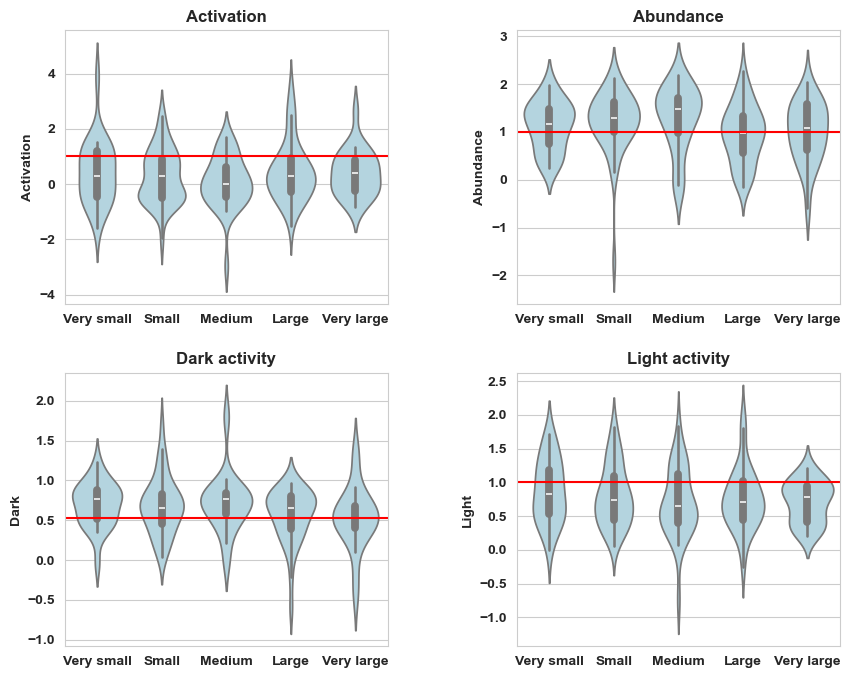

In [39]:
# Property scatter plot
variants_df = data_df.copy()
variants_df = variants_df[['Variant', 'Position', 'variant_type', 'Domain', 'Interaction', 'Dark', 'Light', 'Activation', 'Abundance']]
variants_df['AA'] = variants_df['Variant'].str[-1]
variants_df = variants_df[variants_df['variant_type'] != 'Nonsense']

aa_properties = {
    'A': 'Very small',
    'C': 'Small',
    'I': 'Large',
    'L': 'Large',
    'M': 'Large',
    'F': 'Very large',
    'W': 'Very large',
    'V': 'Medium',
    'G': 'Very small',
    'H': 'Medium',
    'P': 'Small',
    'S': 'Very small',
    'T': 'Small',
    'Y': 'Very large',
    'R': 'Large',
    'N': 'Small',
    'D': 'Small',
    'Q': 'Medium',
    'E': 'Medium',
    'K': 'Large'
}

variants_df['Property'] = variants_df['AA'].map(aa_properties)



# sns.scatterplot(
#     data=variants_df[(variants_df['Interaction'] == 'RBP') & (variants_df['variant_type'] == 'Missense')],
#     x='Activation',
#     y='Abundance',
#     hue='Property',
#     edgecolor=None,
#     alpha=0.6,
#     s=40
# )

# sns.scatterplot(
#     data=variants_df[(variants_df['Interaction'] == 'RBP') & (variants_df['variant_type'] == 'Synonymous')],
#     x='Activation',
#     y='Abundance',
#     color='red',
#     edgecolor=None,
#     alpha=0.6,
#     s=40
# )
# plt.legend(bbox_to_anchor=(1, 1.02))
#
# plt.show()

# Filter to RBP variants
rbp_df = variants_df[variants_df['Interaction'] == 'RBP']

# Set up figure with 2×2 layout
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Shared order for consistent x-axis
prop_order = ['Very small', 'Small', 'Medium', 'Large', 'Very large']

# ---- Plot 1: Activation ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Activation',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[0],
)
axes[0].axhline(y=1, color='red', linestyle='-', linewidth=1.5)
axes[0].set_title('Activation', fontsize=12, weight='bold')
axes[0].set_ylabel('Activation', fontsize=10, weight='bold')

# ---- Plot 2: Abundance ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Abundance',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[1],
)
axes[1].axhline(y=1, color='red', linestyle='-', linewidth=1.5)
axes[1].set_title('Abundance', fontsize=12, weight='bold')
axes[1].set_ylabel('Abundance', fontsize=10, weight='bold')

# ---- Plot 3: Dark ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Dark',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[2],
)
axes[2].axhline(y=0.53, color='red', linestyle='-', linewidth=1.5)
axes[2].set_title('Dark activity', fontsize=12, weight='bold')
axes[2].set_ylabel('Dark', fontsize=10, weight='bold')

# ---- Plot 4: Light ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Light',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[3],
)
axes[3].axhline(y=1, color='red', linestyle='-', linewidth=1.5)
axes[3].set_title('Light activity', fontsize=12, weight='bold')
axes[3].set_ylabel('Light', fontsize=10, weight='bold')

for ax in axes:
    ax.set_xlabel('')


# Adjust subplot spacing
plt.subplots_adjust(wspace=0.4, hspace=0.25)
plt.show()# hide "Property" label

del variants_df, aa_properties, rbp_df, fig, axes

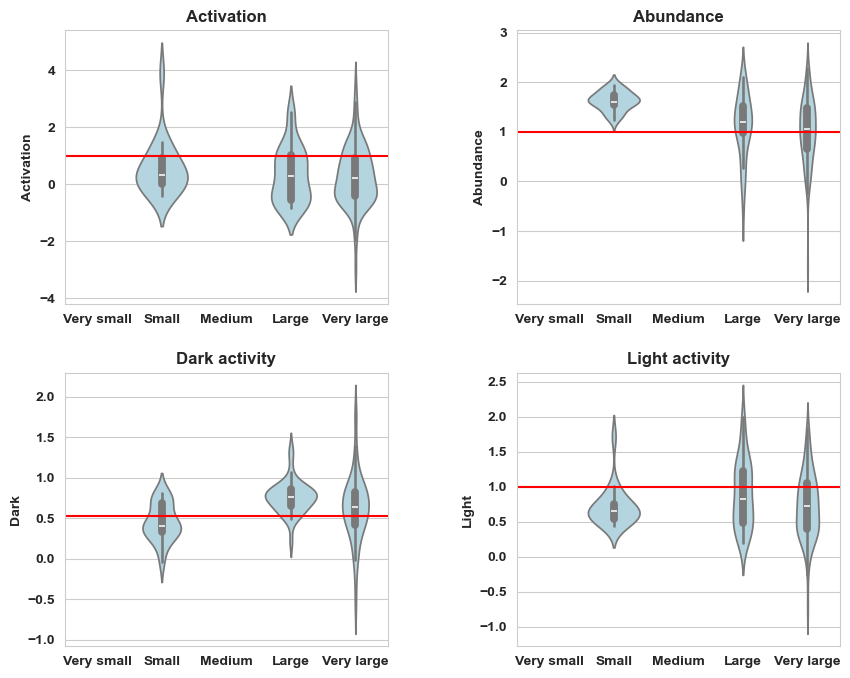

In [40]:
# Property scatter plot
variants_df = data_df.copy()
variants_df = variants_df[['Variant', 'Position', 'variant_type', 'Domain', 'Interaction', 'Dark', 'Light', 'Activation', 'Abundance']]
variants_df['AA'] = variants_df['Variant'].str[0]
variants_df = variants_df[variants_df['variant_type'] != 'Nonsense']

aa_properties = {
    'A': 'Very small',
    'C': 'Small',
    'I': 'Large',
    'L': 'Large',
    'M': 'Large',
    'F': 'Very large',
    'W': 'Very large',
    'V': 'Medium',
    'G': 'Very small',
    'H': 'Medium',
    'P': 'Small',
    'S': 'Very small',
    'T': 'Small',
    'Y': 'Very large',
    'R': 'Large',
    'N': 'Small',
    'D': 'Small',
    'Q': 'Medium',
    'E': 'Medium',
    'K': 'Large'
}

variants_df['Property'] = variants_df['AA'].map(aa_properties)



# sns.scatterplot(
#     data=variants_df[(variants_df['Interaction'] == 'RBP') & (variants_df['variant_type'] == 'Missense')],
#     x='Activation',
#     y='Abundance',
#     hue='Property',
#     edgecolor=None,
#     alpha=0.6,
#     s=40
# )

# sns.scatterplot(
#     data=variants_df[(variants_df['Interaction'] == 'RBP') & (variants_df['variant_type'] == 'Synonymous')],
#     x='Activation',
#     y='Abundance',
#     color='red',
#     edgecolor=None,
#     alpha=0.6,
#     s=40
# )
# plt.legend(bbox_to_anchor=(1, 1.02))
#
# plt.show()

# Filter to RBP variants
rbp_df = variants_df[variants_df['Interaction'] == 'RBP']

# Set up figure with 2×2 layout
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Shared order for consistent x-axis
prop_order = ['Very small', 'Small', 'Medium', 'Large', 'Very large']

# ---- Plot 1: Activation ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Activation',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[0],
)
axes[0].axhline(y=1, color='red', linestyle='-', linewidth=1.5)
axes[0].set_title('Activation', fontsize=12, weight='bold')
axes[0].set_ylabel('Activation', fontsize=10, weight='bold')

# ---- Plot 2: Abundance ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Abundance',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[1],
)
axes[1].axhline(y=1, color='red', linestyle='-', linewidth=1.5)
axes[1].set_title('Abundance', fontsize=12, weight='bold')
axes[1].set_ylabel('Abundance', fontsize=10, weight='bold')

# ---- Plot 3: Dark ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Dark',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[2],
)
axes[2].axhline(y=0.53, color='red', linestyle='-', linewidth=1.5)
axes[2].set_title('Dark activity', fontsize=12, weight='bold')
axes[2].set_ylabel('Dark', fontsize=10, weight='bold')

# ---- Plot 4: Light ----
sns.violinplot(
    data=rbp_df,
    x='Property', y='Light',
    order=prop_order,
    color='#ADD8E6',
    ax=axes[3],
)
axes[3].axhline(y=1, color='red', linestyle='-', linewidth=1.5)
axes[3].set_title('Light activity', fontsize=12, weight='bold')
axes[3].set_ylabel('Light', fontsize=10, weight='bold')

for ax in axes:
    ax.set_xlabel('')


# Adjust subplot spacing
plt.subplots_adjust(wspace=0.4, hspace=0.25)
plt.show()# hide "Property" label

del variants_df, aa_properties, rbp_df, fig, axes

Total variants (RBP): 160
                       quadrant  count  proportion
0     Top-Right (↑Light, ↑Dark)     38      0.2375
1      Top-Left (↓Light, ↑Dark)     66      0.4125
2  Bottom-Right (↑Light, ↓Dark)      7      0.0438
3   Bottom-Left (↓Light, ↓Dark)     45      0.2812


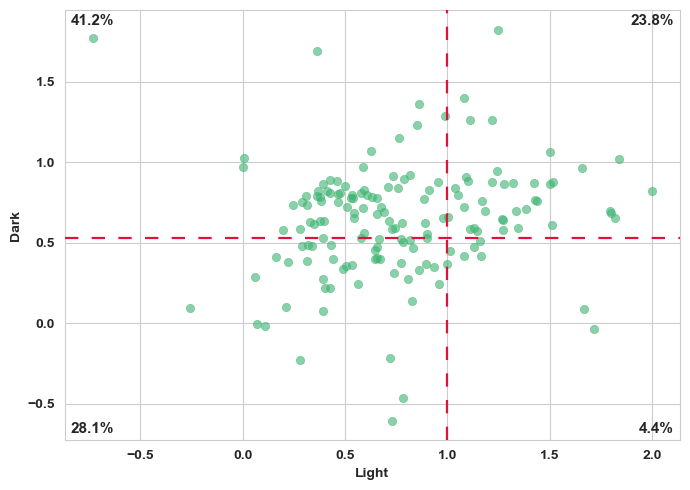

Total variants (RBP): 100
                       quadrant  count  proportion
0     Top-Right (↑Light, ↑Dark)      9        0.09
1      Top-Left (↓Light, ↑Dark)     29        0.29
2  Bottom-Right (↑Light, ↓Dark)      5        0.05
3   Bottom-Left (↓Light, ↓Dark)     54        0.54


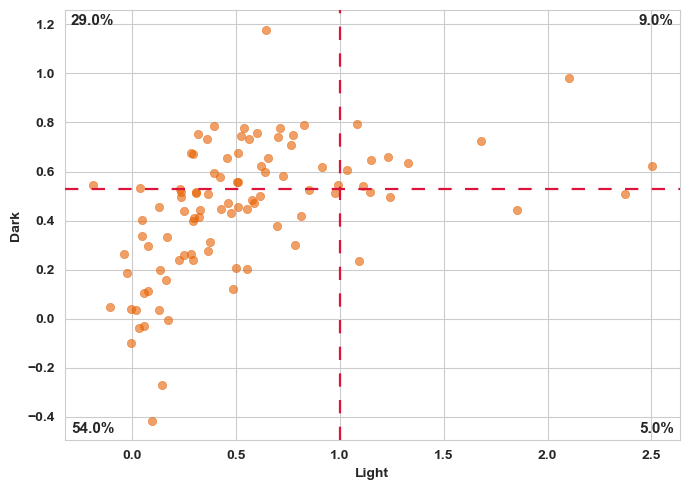

Total variants (RBP): 1760
                       quadrant  count  proportion
0     Top-Right (↑Light, ↑Dark)    653      0.3710
1      Top-Left (↓Light, ↑Dark)    357      0.2028
2  Bottom-Right (↑Light, ↓Dark)    240      0.1364
3   Bottom-Left (↓Light, ↓Dark)    417      0.2369


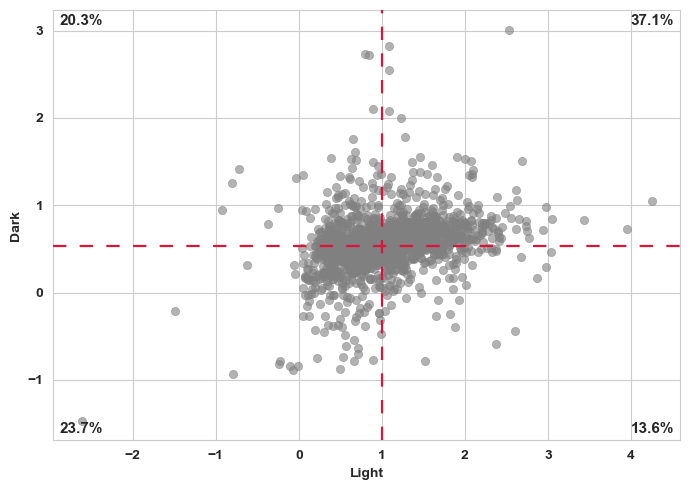

Total variants (RBP): 160
                       quadrant  count  proportion
0     Top-Right (↑Light, ↑Dark)     38      0.2375
1      Top-Left (↓Light, ↑Dark)     66      0.4125
2  Bottom-Right (↑Light, ↓Dark)      7      0.0438
3   Bottom-Left (↓Light, ↓Dark)     45      0.2812


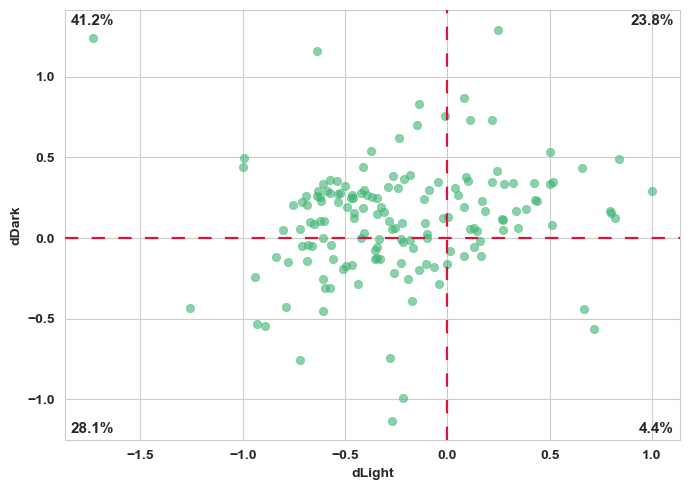

Total variants (RBP): 100
                       quadrant  count  proportion
0     Top-Right (↑Light, ↑Dark)      9        0.09
1      Top-Left (↓Light, ↑Dark)     29        0.29
2  Bottom-Right (↑Light, ↓Dark)      5        0.05
3   Bottom-Left (↓Light, ↓Dark)     54        0.54


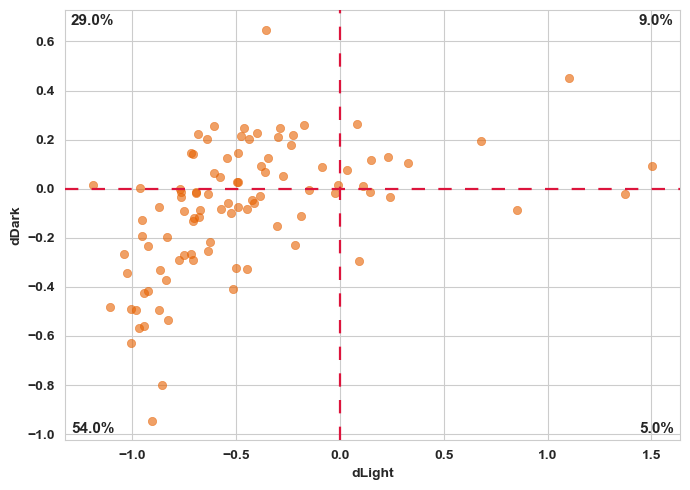

Total variants (RBP): 1760
                       quadrant  count  proportion
0     Top-Right (↑Light, ↑Dark)    653      0.3710
1      Top-Left (↓Light, ↑Dark)    357      0.2028
2  Bottom-Right (↑Light, ↓Dark)    240      0.1364
3   Bottom-Left (↓Light, ↓Dark)    417      0.2369


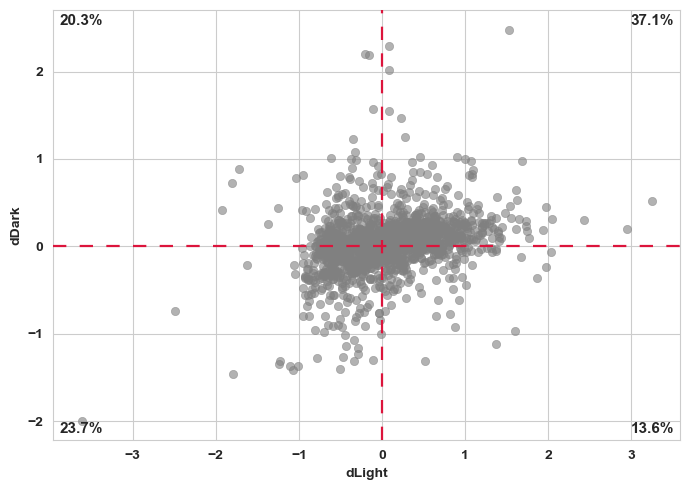

In [41]:
# --- prep ---
variants_df = data_df.copy()
variants_df = variants_df[['Variant', 'Position', 'variant_type', 'Domain', 'Interaction', 'Dark', 'Light']]
variants_df = variants_df[variants_df['variant_type'] != 'Nonsense']
rbp_df = variants_df[variants_df['Interaction'] == 'RBP']

# --- thresholds ---
dark_thr  = 0.53
light_thr = 1.00

# --- scatter ---
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(
    data=rbp_df,
    x='Light', y='Dark',
    color='#3CB371',
    edgecolor=None, alpha=0.6, ax=ax
)

# remember limits *before* drawing lines so lines span full panel
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# --- nicer threshold lines (dashed, slightly thicker, on top of grid) ---
ax.axhline(dark_thr,  linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)
ax.axvline(light_thr, linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)


# restore limits (keeps lines spanning full panel)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel('Light', weight='bold')
ax.set_ylabel('Dark', weight='bold')

plt.tight_layout()

# --- quadrant proportions ---
N = len(rbp_df)

q_TR = (rbp_df['Light'] >= light_thr) & (rbp_df['Dark'] >= dark_thr)   # top-right
q_TL = (rbp_df['Light'] <  light_thr) & (rbp_df['Dark'] >= dark_thr)   # top-left
q_BR = (rbp_df['Light'] >= light_thr) & (rbp_df['Dark'] <  dark_thr)   # bottom-right
q_BL = (rbp_df['Light'] <  light_thr) & (rbp_df['Dark'] <  dark_thr)   # bottom-left

summary = pd.DataFrame({
    'quadrant': ['Top-Right (↑Light, ↑Dark)',
                 'Top-Left (↓Light, ↑Dark)',
                 'Bottom-Right (↑Light, ↓Dark)',
                 'Bottom-Left (↓Light, ↓Dark)'],
    'count':    [q_TR.sum(), q_TL.sum(), q_BR.sum(), q_BL.sum()]
})
summary['proportion'] = (summary['count'] / N).round(4)

print(f"Total variants (RBP): {N}")
print(summary)

# Place quadrant percentages near the corners
offset = 0.01  # fractional offset from edges

ax.text(x_max - offset*(x_max-x_min), y_max - offset*(y_max-y_min),
        f"{(q_TR.sum()/N):.1%}", ha='right', va='top', fontsize=11, weight='bold')

ax.text(x_min + offset*(x_max-x_min), y_max - offset*(y_max-y_min),
        f"{(q_TL.sum()/N):.1%}", ha='left', va='top', fontsize=11, weight='bold')

ax.text(x_max - offset*(x_max-x_min), y_min + offset*(y_max-y_min),
        f"{(q_BR.sum()/N):.1%}", ha='right', va='bottom', fontsize=11, weight='bold')

ax.text(x_min + offset*(x_max-x_min), y_min + offset*(y_max-y_min),
        f"{(q_BL.sum()/N):.1%}", ha='left', va='bottom', fontsize=11, weight='bold')

plt.show()

# cleanup (optional)
del variants_df, rbp_df

# --- prep ---
variants_df = data_df.copy()
variants_df = variants_df[['Variant', 'Position', 'variant_type', 'Domain', 'Interaction', 'Dark', 'Light']]
variants_df = variants_df[variants_df['variant_type'] != 'Nonsense']
gpi_df = variants_df[variants_df['Interaction'] == 'GPI']

# --- thresholds ---
dark_thr  = 0.53
light_thr = 1.00

# --- scatter ---
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(
    data=gpi_df,
    x='Light', y='Dark',
    color='#E66100',
    edgecolor=None, alpha=0.6, ax=ax
)

# remember limits *before* drawing lines so lines span full panel
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# --- nicer threshold lines (dashed, slightly thicker, on top of grid) ---
ax.axhline(dark_thr,  linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)
ax.axvline(light_thr, linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)


# restore limits (keeps lines spanning full panel)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel('Light', weight='bold')
ax.set_ylabel('Dark', weight='bold')

plt.tight_layout()

# --- quadrant proportions ---
N = len(gpi_df)

q_TR = (gpi_df['Light'] >= light_thr) & (gpi_df['Dark'] >= dark_thr)   # top-right
q_TL = (gpi_df['Light'] <  light_thr) & (gpi_df['Dark'] >= dark_thr)   # top-left
q_BR = (gpi_df['Light'] >= light_thr) & (gpi_df['Dark'] <  dark_thr)   # bottom-right
q_BL = (gpi_df['Light'] <  light_thr) & (gpi_df['Dark'] <  dark_thr)   # bottom-left

summary = pd.DataFrame({
    'quadrant': ['Top-Right (↑Light, ↑Dark)',
                 'Top-Left (↓Light, ↑Dark)',
                 'Bottom-Right (↑Light, ↓Dark)',
                 'Bottom-Left (↓Light, ↓Dark)'],
    'count':    [q_TR.sum(), q_TL.sum(), q_BR.sum(), q_BL.sum()]
})
summary['proportion'] = (summary['count'] / N).round(4)

print(f"Total variants (RBP): {N}")
print(summary)

# Place quadrant percentages near the corners
offset = 0.01  # fractional offset from edges

ax.text(x_max - offset*(x_max-x_min), y_max - offset*(y_max-y_min),
        f"{(q_TR.sum()/N):.1%}", ha='right', va='top', fontsize=11, weight='bold')

ax.text(x_min + offset*(x_max-x_min), y_max - offset*(y_max-y_min),
        f"{(q_TL.sum()/N):.1%}", ha='left', va='top', fontsize=11, weight='bold')

ax.text(x_max - offset*(x_max-x_min), y_min + offset*(y_max-y_min),
        f"{(q_BR.sum()/N):.1%}", ha='right', va='bottom', fontsize=11, weight='bold')

ax.text(x_min + offset*(x_max-x_min), y_min + offset*(y_max-y_min),
        f"{(q_BL.sum()/N):.1%}", ha='left', va='bottom', fontsize=11, weight='bold')

plt.show()

# cleanup (optional)
del variants_df, gpi_df

# --- prep ---
variants_df = data_df.copy()
variants_df = variants_df[['Variant', 'Position', 'variant_type', 'Domain', 'Interaction', 'Dark', 'Light']]
variants_df = variants_df[variants_df['variant_type'] != 'Nonsense']
others_df = variants_df[variants_df['Interaction'] == 'Other']

# --- thresholds ---
dark_thr  = 0.53
light_thr = 1.00

# --- scatter ---
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(
    data=others_df,
    x='Light', y='Dark',
    color='Grey',
    edgecolor=None, alpha=0.6, ax=ax
)

# remember limits *before* drawing lines so lines span full panel
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# --- nicer threshold lines (dashed, slightly thicker, on top of grid) ---
ax.axhline(dark_thr,  linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)
ax.axvline(light_thr, linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)


# restore limits (keeps lines spanning full panel)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel('Light', weight='bold')
ax.set_ylabel('Dark', weight='bold')

plt.tight_layout()

# --- quadrant proportions ---
N = len(others_df)

q_TR = (others_df['Light'] >= light_thr) & (others_df['Dark'] >= dark_thr)   # top-right
q_TL = (others_df['Light'] <  light_thr) & (others_df['Dark'] >= dark_thr)   # top-left
q_BR = (others_df['Light'] >= light_thr) & (others_df['Dark'] <  dark_thr)   # bottom-right
q_BL = (others_df['Light'] <  light_thr) & (others_df['Dark'] <  dark_thr)   # bottom-left

summary = pd.DataFrame({
    'quadrant': ['Top-Right (↑Light, ↑Dark)',
                 'Top-Left (↓Light, ↑Dark)',
                 'Bottom-Right (↑Light, ↓Dark)',
                 'Bottom-Left (↓Light, ↓Dark)'],
    'count':    [q_TR.sum(), q_TL.sum(), q_BR.sum(), q_BL.sum()]
})
summary['proportion'] = (summary['count'] / N).round(4)

print(f"Total variants (RBP): {N}")
print(summary)

# Place quadrant percentages near the corners
offset = 0.01  # fractional offset from edges

ax.text(x_max - offset*(x_max-x_min), y_max - offset*(y_max-y_min),
        f"{(q_TR.sum()/N):.1%}", ha='right', va='top', fontsize=11, weight='bold')

ax.text(x_min + offset*(x_max-x_min), y_max - offset*(y_max-y_min),
        f"{(q_TL.sum()/N):.1%}", ha='left', va='top', fontsize=11, weight='bold')

ax.text(x_max - offset*(x_max-x_min), y_min + offset*(y_max-y_min),
        f"{(q_BR.sum()/N):.1%}", ha='right', va='bottom', fontsize=11, weight='bold')

ax.text(x_min + offset*(x_max-x_min), y_min + offset*(y_max-y_min),
        f"{(q_BL.sum()/N):.1%}", ha='left', va='bottom', fontsize=11, weight='bold')

plt.show()

# cleanup (optional)
del variants_df, others_df

# --- prep ---
variants_df = data_df.copy()
variants_df = variants_df[['Variant', 'Position', 'variant_type', 'Domain', 'Interaction', 'Dark', 'Light']]
variants_df['dDark'] = variants_df['Dark'] - 0.53
variants_df['dLight'] = variants_df['Light'] - 1
variants_df = variants_df[variants_df['variant_type'] != 'Nonsense']
rbp_df = variants_df[variants_df['Interaction'] == 'RBP']

# --- thresholds ---
dark_thr  = 0
light_thr = 0

# --- scatter ---
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(
    data=rbp_df,
    x='dLight', y='dDark',
    color='#3CB371',
    edgecolor=None, alpha=0.6, ax=ax
)

# remember limits *before* drawing lines so lines span full panel
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# --- nicer threshold lines (dashed, slightly thicker, on top of grid) ---
ax.axhline(dark_thr,  linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)
ax.axvline(light_thr, linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)


# restore limits (keeps lines spanning full panel)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel('dLight', weight='bold')
ax.set_ylabel('dDark', weight='bold')

plt.tight_layout()

# --- quadrant proportions ---
N = len(rbp_df)

q_TR = (rbp_df['dLight'] >= light_thr) & (rbp_df['dDark'] >= dark_thr)   # top-right
q_TL = (rbp_df['dLight'] <  light_thr) & (rbp_df['dDark'] >= dark_thr)   # top-left
q_BR = (rbp_df['dLight'] >= light_thr) & (rbp_df['dDark'] <  dark_thr)   # bottom-right
q_BL = (rbp_df['dLight'] <  light_thr) & (rbp_df['dDark'] <  dark_thr)   # bottom-left

summary = pd.DataFrame({
    'quadrant': ['Top-Right (↑Light, ↑Dark)',
                 'Top-Left (↓Light, ↑Dark)',
                 'Bottom-Right (↑Light, ↓Dark)',
                 'Bottom-Left (↓Light, ↓Dark)'],
    'count':    [q_TR.sum(), q_TL.sum(), q_BR.sum(), q_BL.sum()]
})
summary['proportion'] = (summary['count'] / N).round(4)

print(f"Total variants (RBP): {N}")
print(summary)

# Place quadrant percentages near the corners
offset = 0.01  # fractional offset from edges

ax.text(x_max - offset*(x_max-x_min), y_max - offset*(y_max-y_min),
        f"{(q_TR.sum()/N):.1%}", ha='right', va='top', fontsize=11, weight='bold')

ax.text(x_min + offset*(x_max-x_min), y_max - offset*(y_max-y_min),
        f"{(q_TL.sum()/N):.1%}", ha='left', va='top', fontsize=11, weight='bold')

ax.text(x_max - offset*(x_max-x_min), y_min + offset*(y_max-y_min),
        f"{(q_BR.sum()/N):.1%}", ha='right', va='bottom', fontsize=11, weight='bold')

ax.text(x_min + offset*(x_max-x_min), y_min + offset*(y_max-y_min),
        f"{(q_BL.sum()/N):.1%}", ha='left', va='bottom', fontsize=11, weight='bold')

plt.show()

# cleanup (optional)
del variants_df, rbp_df

# --- prep ---
variants_df = data_df.copy()
variants_df = variants_df[['Variant', 'Position', 'variant_type', 'Domain', 'Interaction', 'Dark', 'Light']]
variants_df['dDark'] = variants_df['Dark'] - 0.53
variants_df['dLight'] = variants_df['Light'] - 1
variants_df = variants_df[variants_df['variant_type'] != 'Nonsense']
gpi_df = variants_df[variants_df['Interaction'] == 'GPI']

# --- thresholds ---
dark_thr  = 0
light_thr = 0

# --- scatter ---
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(
    data=gpi_df,
    x='dLight', y='dDark',
    color='#E66100',
    edgecolor=None, alpha=0.6, ax=ax
)

# remember limits *before* drawing lines so lines span full panel
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# --- nicer threshold lines (dashed, slightly thicker, on top of grid) ---
ax.axhline(dark_thr,  linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)
ax.axvline(light_thr, linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)


# restore limits (keeps lines spanning full panel)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel('dLight', weight='bold')
ax.set_ylabel('dDark', weight='bold')

plt.tight_layout()

# --- quadrant proportions ---
N = len(gpi_df)

q_TR = (gpi_df['dLight'] >= light_thr) & (gpi_df['dDark'] >= dark_thr)   # top-right
q_TL = (gpi_df['dLight'] <  light_thr) & (gpi_df['dDark'] >= dark_thr)   # top-left
q_BR = (gpi_df['dLight'] >= light_thr) & (gpi_df['dDark'] <  dark_thr)   # bottom-right
q_BL = (gpi_df['dLight'] <  light_thr) & (gpi_df['dDark'] <  dark_thr)   # bottom-left

summary = pd.DataFrame({
    'quadrant': ['Top-Right (↑Light, ↑Dark)',
                 'Top-Left (↓Light, ↑Dark)',
                 'Bottom-Right (↑Light, ↓Dark)',
                 'Bottom-Left (↓Light, ↓Dark)'],
    'count':    [q_TR.sum(), q_TL.sum(), q_BR.sum(), q_BL.sum()]
})
summary['proportion'] = (summary['count'] / N).round(4)

print(f"Total variants (RBP): {N}")
print(summary)

# Place quadrant percentages near the corners
offset = 0.01  # fractional offset from edges

ax.text(x_max - offset*(x_max-x_min), y_max - offset*(y_max-y_min),
        f"{(q_TR.sum()/N):.1%}", ha='right', va='top', fontsize=11, weight='bold')

ax.text(x_min + offset*(x_max-x_min), y_max - offset*(y_max-y_min),
        f"{(q_TL.sum()/N):.1%}", ha='left', va='top', fontsize=11, weight='bold')

ax.text(x_max - offset*(x_max-x_min), y_min + offset*(y_max-y_min),
        f"{(q_BR.sum()/N):.1%}", ha='right', va='bottom', fontsize=11, weight='bold')

ax.text(x_min + offset*(x_max-x_min), y_min + offset*(y_max-y_min),
        f"{(q_BL.sum()/N):.1%}", ha='left', va='bottom', fontsize=11, weight='bold')

plt.show()

# cleanup (optional)
del variants_df, gpi_df

# --- prep ---
variants_df = data_df.copy()
variants_df = variants_df[['Variant', 'Position', 'variant_type', 'Domain', 'Interaction', 'Dark', 'Light']]
variants_df['dDark'] = variants_df['Dark'] - 0.53
variants_df['dLight'] = variants_df['Light'] - 1
variants_df = variants_df[variants_df['variant_type'] != 'Nonsense']
others_df = variants_df[variants_df['Interaction'] == 'Other']

# --- thresholds ---
dark_thr  = 0
light_thr = 0

# --- scatter ---
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(
    data=others_df,
    x='dLight', y='dDark',
    color='Grey',
    edgecolor=None, alpha=0.6, ax=ax
)

# remember limits *before* drawing lines so lines span full panel
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# --- nicer threshold lines (dashed, slightly thicker, on top of grid) ---
ax.axhline(dark_thr,  linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)
ax.axvline(light_thr, linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)


# restore limits (keeps lines spanning full panel)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel('dLight', weight='bold')
ax.set_ylabel('dDark', weight='bold')

plt.tight_layout()

# --- quadrant proportions ---
N = len(others_df)

q_TR = (others_df['dLight'] >= light_thr) & (others_df['dDark'] >= dark_thr)   # top-right
q_TL = (others_df['dLight'] <  light_thr) & (others_df['dDark'] >= dark_thr)   # top-left
q_BR = (others_df['dLight'] >= light_thr) & (others_df['dDark'] <  dark_thr)   # bottom-right
q_BL = (others_df['dLight'] <  light_thr) & (others_df['dDark'] <  dark_thr)   # bottom-left

summary = pd.DataFrame({
    'quadrant': ['Top-Right (↑Light, ↑Dark)',
                 'Top-Left (↓Light, ↑Dark)',
                 'Bottom-Right (↑Light, ↓Dark)',
                 'Bottom-Left (↓Light, ↓Dark)'],
    'count':    [q_TR.sum(), q_TL.sum(), q_BR.sum(), q_BL.sum()]
})
summary['proportion'] = (summary['count'] / N).round(4)

print(f"Total variants (RBP): {N}")
print(summary)

# Place quadrant percentages near the corners
offset = 0.01  # fractional offset from edges

ax.text(x_max - offset*(x_max-x_min), y_max - offset*(y_max-y_min),
        f"{(q_TR.sum()/N):.1%}", ha='right', va='top', fontsize=11, weight='bold')

ax.text(x_min + offset*(x_max-x_min), y_max - offset*(y_max-y_min),
        f"{(q_TL.sum()/N):.1%}", ha='left', va='top', fontsize=11, weight='bold')

ax.text(x_max - offset*(x_max-x_min), y_min + offset*(y_max-y_min),
        f"{(q_BR.sum()/N):.1%}", ha='right', va='bottom', fontsize=11, weight='bold')

ax.text(x_min + offset*(x_max-x_min), y_min + offset*(y_max-y_min),
        f"{(q_BL.sum()/N):.1%}", ha='left', va='bottom', fontsize=11, weight='bold')

plt.show()

# cleanup (optional)
del variants_df, others_df

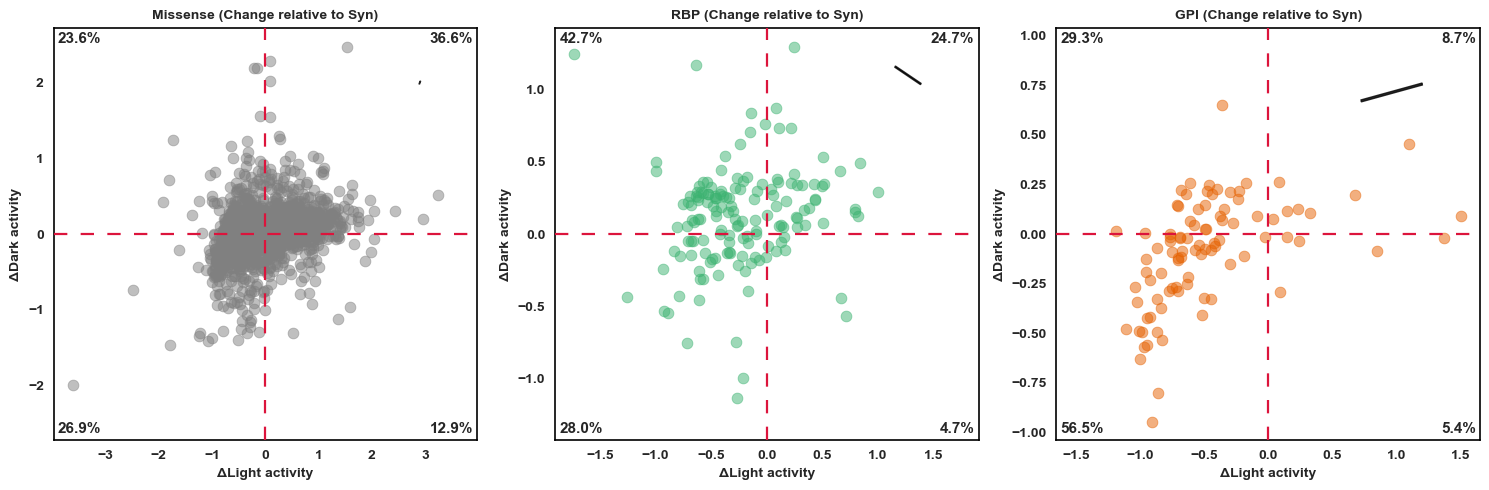

,Interaction,Type,Variant,Quadrant,dLight,dDark
0,RBP,ΔRelative,C187A,"Bottom-Right (↑Light, ↓Dark)",0.014805,-0.080903
1,RBP,ΔRelative,C187D,"Bottom-Left (↓Light, ↓Dark)",-0.354675,-0.130056
2,RBP,ΔRelative,C187E,"Bottom-Left (↓Light, ↓Dark)",-0.327054,-0.127549
3,RBP,ΔRelative,C187F,"Top-Left (↓Light, ↑Dark)",-0.453992,0.156057
4,RBP,ΔRelative,C187G,"Bottom-Left (↓Light, ↓Dark)",-0.494042,-0.173623
...,...,...,...,...,...,...
2061,Missense,ΔRelative,T277R,"Top-Right (↑Light, ↑Dark)",0.546668,0.159210
2062,Missense,ΔRelative,T277S,"Top-Right (↑Light, ↑Dark)",0.145743,0.104234
2063,Missense,ΔRelative,T277V,"Bottom-Left (↓Light, ↓Dark)",-0.169121,-0.050769
2064,Missense,ΔRelative,T277W,"Top-Right (↑Light, ↑Dark)",0.517650,0.001393


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ---- prep once ----
base = data_df[['Variant','Position','variant_type','Domain','Interaction','Dark','Light']].copy().dropna()
base = base[base['variant_type'] == 'Missense']
base['dDark']  = base['Dark']  - 0.53
base['dLight'] = base['Light'] - 1.00

colors = {
    'RBP':   '#3CB371',  # green
    'GPI':   '#E66100',  # orange
    'Missense': 'grey'
}

def get_quadrant_df(df, xcol, ycol, xthr, ythr, interaction, level):
    """Return DataFrame with quadrant assignment per variant."""
    out = df.copy()

    # start as object dtype to avoid dtype promotion issues
    quadrant = pd.Series([None] * len(out), index=out.index, dtype="object")

    # masks
    m_TR = (out[xcol] >= xthr) & (out[ycol] >= ythr)
    m_TL = (out[xcol] <  xthr) & (out[ycol] >= ythr)
    m_BR = (out[xcol] >= xthr) & (out[ycol] <  ythr)
    m_BL = (out[xcol] <  xthr) & (out[ycol] <  ythr)

    # assign labels
    quadrant[m_TR] = 'Top-Right (↑Light, ↑Dark)'
    quadrant[m_TL] = 'Top-Left (↓Light, ↑Dark)'
    quadrant[m_BR] = 'Bottom-Right (↑Light, ↓Dark)'
    quadrant[m_BL] = 'Bottom-Left (↓Light, ↓Dark)'

    # store as ordered categorical (optional)
    labels = [
        'Top-Right (↑Light, ↑Dark)',
        'Top-Left (↓Light, ↑Dark)',
        'Bottom-Right (↑Light, ↓Dark)',
        'Bottom-Left (↓Light, ↓Dark)',
    ]
    out['Quadrant'] = pd.Categorical(quadrant, categories=labels, ordered=True)

    out['Interaction'] = interaction
    out['Type'] = level
    return out[['Interaction', 'Type', 'Variant', 'Quadrant', xcol, ycol]]

def draw_panel(ax, df, xcol, ycol, xthr, ythr, color, title, xlabel, ylabel, show_arrow=True):
    """Draw scatter panel with threshold lines and quadrant proportions."""
    sns.scatterplot(data=df, x=xcol, y=ycol, color=color, edgecolor=None, s=60, alpha=0.5, ax=ax)
    plt.rcParams["svg.fonttype"] = "none"

    # Compute symmetric axis limits centered on 0
    max_abs_x = max(abs(df[xcol].min()), abs(df[xcol].max()))
    max_abs_y = max(abs(df[ycol].min()), abs(df[ycol].max()))
    margin_x = 0.1 * max_abs_x
    margin_y = 0.1 * max_abs_y
    ax.set_xlim(-max_abs_x - margin_x, max_abs_x + margin_x)
    ax.set_ylim(-max_abs_y - margin_y, max_abs_y + margin_y)

    # Draw a single arrow showing the mean shift
    if show_arrow and len(df) > 0:
        mean_x = df[xcol].mean()
        mean_y = df[ycol].mean()
        ax.arrow(0.8*max_abs_x, 0.8*max_abs_y, mean_x, mean_y,
                 color='black', width=0.01, head_width=0, length_includes_head=False,
                 alpha=0.8, zorder=4)

    # Threshold lines
    ax.axvline(xthr, linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)
    ax.axhline(ythr, linestyle=(0,(6,6)), linewidth=1.6, color='crimson', zorder=3)

    # Labels and style
    ax.set_title(title, weight='bold', font='Arial')
    ax.set_xlabel(xlabel, weight='bold', font='Arial')
    ax.set_ylabel(ylabel, weight='bold', font='Arial')
    ax.set_facecolor('white')
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color('black')

    # Quadrant proportions
    N = len(df)
    if N == 0:
        return
    q_TR = (df[xcol] >= xthr) & (df[ycol] >= ythr)
    q_TL = (df[xcol] <  xthr) & (df[ycol] >= ythr)
    q_BR = (df[xcol] >= xthr) & (df[ycol] <  ythr)
    q_BL = (df[xcol] <  xthr) & (df[ycol] <  ythr)

    offset = 0.01
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    ax.text(x_max - offset*(x_max-x_min), y_max - offset*(y_max-y_min), f"{(q_TR.sum()/N):.1%}",
            ha='right', va='top', fontsize=11, weight='bold', font='Arial')
    ax.text(x_min + offset*(x_max-x_min), y_max - offset*(y_max-y_min), f"{(q_TL.sum()/N):.1%}",
            ha='left',  va='top', fontsize=11, weight='bold', font='Arial')
    ax.text(x_max - offset*(x_max-x_min), y_min + offset*(y_max-y_min), f"{(q_BR.sum()/N):.1%}",
            ha='right', va='bottom', fontsize=11, weight='bold', font='Arial')
    ax.text(x_min + offset*(x_max-x_min), y_min + offset*(y_max-y_min), f"{(q_BL.sum()/N):.1%}",
            ha='left',  va='bottom', fontsize=11, weight='bold', font='Arial')


# ---- split dataframes ----
rbp   = base[base['Interaction'] == 'RBP']
gpi   = base[base['Interaction'] == 'GPI']
missense = base

# ---- figure: 1 x 3 (ΔLight vs ΔDark) ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

draw_panel(axes[0], missense, 'dLight','dDark', 0, 0, colors['Missense'], 'Missense (Change relative to Syn)', 'ΔLight activity', 'ΔDark activity')
draw_panel(axes[1], rbp,   'dLight','dDark', 0, 0, colors['RBP'],   'RBP (Change relative to Syn)',   'ΔLight activity', 'ΔDark activity')
draw_panel(axes[2], gpi,   'dLight','dDark', 0, 0, colors['GPI'],   'GPI (Change relative to Syn)',   'ΔLight activity', 'ΔDark activity')




plt.tight_layout()
plt.savefig("delta_light_dark_scatter.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()

# ---- Collect quadrant info into one DataFrame ----
quadrant_df = pd.concat([
    get_quadrant_df(rbp,   'dLight','dDark', 0.0,  0.0,  'RBP',   'ΔRelative'),
    get_quadrant_df(gpi,   'dLight','dDark', 0.0,  0.0,  'GPI',   'ΔRelative'),
    get_quadrant_df(missense, 'dLight','dDark', 0.0,  0.0,  'Missense', 'ΔRelative'),
], ignore_index=True)

# Display DataFrame
quadrant_df




      Group     n  mean_Light  mean_Dark   angle_deg         T2   sqrt_T2  \
0       GPI    92   -0.477159  -0.085118 -169.885697  82.862899  9.102906   
1       RBP   150   -0.231075   0.119873  152.581340  63.033325  7.939353   
2  Missense  1824    0.017979   0.037730   64.521821  22.240788  4.716014   

   p_perm  
0  0.0001  
1  0.0001  
2  0.0001  


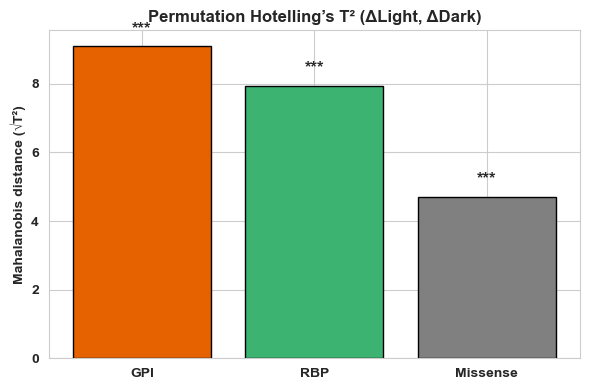

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Permutation Hotelling's T^2
# -----------------------------
def _safe_inv(cov, ridge=1e-8):
    """Numerically safe inverse of covariance."""
    p = cov.shape[0]
    return np.linalg.pinv(cov + ridge * np.eye(p))

def hotelling_T2(X, inv_cov=None):
    """
    Compute Hotelling's T^2 for testing mean(X)=0 using sample covariance.
    X: (n, p) array
    """
    X = np.asarray(X)
    n, p = X.shape
    mean_vec = X.mean(axis=0)
    cov = np.cov(X, rowvar=False)
    if inv_cov is None:
        inv_cov = _safe_inv(cov)
    T2 = float(n * mean_vec @ inv_cov @ mean_vec)
    return T2, mean_vec, cov

def perm_hotelling_T2(X, B=10000, rng=None):
    """
    Sign-flip permutation Hotelling's T^2 test for H0: mean = 0.
    Returns: dict with T2_obs, p_perm, mean_vec, cov, angle_deg, sqrt_T2
    """
    X = np.asarray(X)
    n, p = X.shape
    if rng is None:
        rng = np.random.default_rng(0)

    # observed statistic
    T2_obs, mean_vec, cov = hotelling_T2(X)
    inv_cov = _safe_inv(cov)

    # build null via random sign flips that preserve covariance structure
    null_stats = np.empty(B, dtype=float)
    for b in range(B):
        signs = rng.choice([1, -1], size=n)
        X_null = X * signs[:, None]
        # reuse inv_cov from observed sample (common, stable choice)
        m_null = X_null.mean(axis=0)
        null_stats[b] = float(n * m_null @ inv_cov @ m_null)

    p_perm = (np.sum(null_stats >= T2_obs) + 1) / (B + 1)

    angle_deg = float(np.degrees(np.arctan2(mean_vec[1], mean_vec[0])))
    return {
        "T2_obs": T2_obs,
        "sqrt_T2": float(np.sqrt(T2_obs)),
        "p_perm": p_perm,
        "mean_vec": mean_vec,
        "cov": cov,
        "angle_deg": angle_deg,
        "n": n,
    }

def run_groups_perm_T2(groups_dict, B=10000, seed=0):
    """
    groups_dict: {'RBP': rbp[['dLight','dDark']], 'GPI': gpi[[...]], ...}
    Returns tidy DataFrame with results for all groups.
    """
    rng = np.random.default_rng(seed)
    rows = []
    for name, df in groups_dict.items():
        X = df[['dLight','dDark']].dropna().to_numpy()
        res = perm_hotelling_T2(X, B=B, rng=rng)
        rows.append({
            "Group": name,
            "n": res["n"],
            "mean_Light": res["mean_vec"][0],
            "mean_Dark": res["mean_vec"][1],
            "angle_deg": res["angle_deg"],
            "T2": res["T2_obs"],
            "sqrt_T2": res["sqrt_T2"],
            "p_perm": res["p_perm"],
        })
    out = pd.DataFrame(rows).sort_values("sqrt_T2", ascending=False)
    return out.reset_index(drop=True)

def p_to_stars(p):
    return "***" if p < 1e-3 else ("**" if p < 1e-2 else ("*" if p < 5e-2 else "ns"))

def plot_sqrtT2_bars(summary_df, colors=None, title="Permutation Hotelling’s T²"):
    """
    Simple √T² bar plot with significance stars.
    colors: dict mapping group -> color (e.g., {'RBP':'#3CB371', 'GPI':'#E66100', 'Other':'grey'})
    """
    if colors is None:
        colors = {g:'#999999' for g in summary_df['Group']}
    xs = np.arange(len(summary_df))
    ys = summary_df["sqrt_T2"].values
    cols = [colors.get(g, '#999999') for g in summary_df['Group']]
    plt.figure(figsize=(6,4))
    plt.bar(xs, ys, color=cols, edgecolor='black')
    for i, (y, p) in enumerate(zip(ys, summary_df["p_perm"].values)):
        plt.text(i, y + 0.3, p_to_stars(p), ha='center', va='bottom', fontsize=12, fontweight='bold')
    plt.xticks(xs, summary_df["Group"].tolist())
    plt.ylabel("Mahalanobis distance (√T²)", weight='bold')
    plt.title(title, weight='bold')
    plt.tight_layout()
    plt.show()

# -----------------------------
# RUN on your three groups
# -----------------------------
groups = {
    "RBP":   rbp[['dLight','dDark']],
    "GPI":   gpi[['dLight','dDark']],
    "Missense": missense[['dLight','dDark']],
}
perm_summary = run_groups_perm_T2(groups, B=10000, seed=42)
print(perm_summary)

# Optional bar plot
palette = {'RBP':'#3CB371','GPI':'#E66100','Missense':'grey'}
plot_sqrtT2_bars(perm_summary, colors=palette, title="Permutation Hotelling’s T² (ΔLight, ΔDark)")


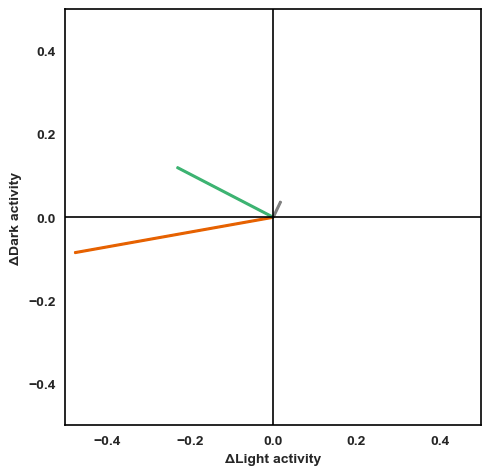

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# summarized results from your output
summary = perm_summary.copy()


# --- Panel B: Direction arrows (ΔLight vs ΔDark) ---
plt.figure(figsize=(5,5))  # square
plt.rcParams["svg.fonttype"] = "none"
ax = plt.gca()

# remove grid & set background
ax.set_facecolor('white')
ax.grid(False)

# draw arrows
for _, row in summary.iterrows():
    ax.arrow(0, 0, row.mean_Light, row.mean_Dark,
             color=palette[row.Group],
             width=0.004, head_width=0,
             length_includes_head=True)

# axes lines
ax.axhline(0, color='black', lw=1.2)
ax.axvline(0, color='black', lw=1.2)

# labels & limits
ax.set_xlabel("ΔLight activity", weight='bold', font='Arial')
ax.set_ylabel("ΔDark activity", weight='bold', font='Arial')
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.5, 0.5)
ax.set_aspect('equal', 'box')  # ensure square aspect ratio

# clean style
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color('black')

plt.tight_layout()
plt.savefig("delta_light_dark_direction.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------- Prep ----------
base = data_df[['Variant','Position','variant_type','Domain','Interaction','Dark','Light']].copy()
base = base[base['variant_type'] != 'Nonsense']
base['dDark']  = base['Dark']  - 0.53
base['dLight'] = base['Light'] - 1.00

rbp   = base[base['Interaction'] == 'RBP']
gpi   = base[base['Interaction'] == 'GPI']
other = base[base['Interaction'] == 'Other']

colors = {'RBP':'#3CB371','GPI':'#E66100','Other':'grey'}

# ---------- Helper functions ----------
def quadrant_percentages(df, xcol, ycol, xthr, ythr):
    """Return quadrant percentages (TR, TL, BR, BL)."""
    if len(df) == 0:
        return (0,0,0,0)
    qTR = ((df[xcol] >= xthr) & (df[ycol] >= ythr)).sum() / len(df)
    qTL = ((df[xcol] <  xthr) & (df[ycol] >= ythr)).sum() / len(df)
    qBR = ((df[xcol] >= xthr) & (df[ycol] <  ythr)).sum() / len(df)
    qBL = ((df[xcol] <  xthr) & (df[ycol] <  ythr)).sum() / len(df)
    return (qTR, qTL, qBR, qBL)

def axis_id(row, col, cols=3):
    """Return Plotly axis suffix ('', '2', '3', ...) for subplot grid."""
    idx = (row - 1) * cols + col
    return "" if idx == 1 else str(idx)

def add_threshold_shapes(fig, row, col, xthr, ythr, xdata, ydata):
    """Draw vertical and horizontal threshold lines for each subplot."""
    if len(xdata) == 0 or len(ydata) == 0:
        return
    x_min, x_max = float(np.nanmin(xdata)), float(np.nanmax(xdata))
    y_min, y_max = float(np.nanmin(ydata)), float(np.nanmax(ydata))
    if not np.isfinite([x_min, x_max, y_min, y_max]).all():
        return

    suf = axis_id(row, col, cols=3)
    xref = f"x{suf}"
    yref = f"y{suf}"

    # vertical line (x = xthr)
    fig.add_shape(
        type="line",
        x0=xthr, x1=xthr, y0=y_min, y1=y_max,
        xref=xref, yref=yref,
        line=dict(color="crimson", width=2, dash="dash")
    )
    # horizontal line (y = ythr)
    fig.add_shape(
        type="line",
        x0=x_min, x1=x_max, y0=ythr, y1=ythr,
        xref=xref, yref=yref,
        line=dict(color="crimson", width=2, dash="dash")
    )

def corner_annotations(fig, row, col, xdata, ydata, pcts):
    """Place quadrant percentage text in corners."""
    if len(xdata) == 0 or len(ydata) == 0:
        return
    x_min, x_max = np.nanmin(xdata), np.nanmax(xdata)
    y_min, y_max = np.nanmin(ydata), np.nanmax(ydata)
    if not np.isfinite([x_min, x_max, y_min, y_max]).all():
        return
    dx = (x_max - x_min) or 1.0
    dy = (y_max - y_min) or 1.0
    off = 0.02
    TR, TL, BR, BL = pcts

    fig.add_annotation(x=x_max - off*dx, y=y_max - off*dy, text=f"{TR:.0%}",
                       showarrow=False, font=dict(size=12, color="black"),
                       xanchor="right", yanchor="top", row=row, col=col)
    fig.add_annotation(x=x_min + off*dx, y=y_max - off*dy, text=f"{TL:.0%}",
                       showarrow=False, font=dict(size=12, color="black"),
                       xanchor="left", yanchor="top", row=row, col=col)
    fig.add_annotation(x=x_max - off*dx, y=y_min + off*dy, text=f"{BR:.0%}",
                       showarrow=False, font=dict(size=12, color="black"),
                       xanchor="right", yanchor="bottom", row=row, col=col)
    fig.add_annotation(x=x_min + off*dx, y=y_min + off*dy, text=f"{BL:.0%}",
                       showarrow=False, font=dict(size=12, color="black"),
                       xanchor="left", yanchor="bottom", row=row, col=col)

def add_panel(fig, row, col, df, xcol, ycol, color, title, xlab, ylab, xthr, ythr):
    """Add one interactive scatter subplot."""
    fig.add_trace(
        go.Scatter(
            x=df[xcol], y=df[ycol],
            mode="markers",
            marker=dict(color=color, opacity=0.7),
            hovertemplate=(
                "<b>%{customdata[0]}</b><br>"
                + f"{xlab}: " + "%{x:.3f}<br>"
                + f"{ylab}: " + "%{y:.3f}<extra></extra>"
            ),
            customdata=np.stack([df['Variant']], axis=-1) if len(df) else None,
            name=title,
            showlegend=False
        ),
        row=row, col=col
    )

    # Force all axes to show lines and ticks
    fig.update_xaxes(showline=True, linewidth=1.5, linecolor='black',
                     mirror=True, showgrid=False, zeroline=False)
    fig.update_yaxes(showline=True, linewidth=1.5, linecolor='black',
                     mirror=True, showgrid=False, zeroline=False)

    # threshold lines
    add_threshold_shapes(fig, row, col, xthr, ythr, df[xcol].values, df[ycol].values)

    # corner % text
    pcts = quadrant_percentages(df, xcol, ycol, xthr, ythr)
    corner_annotations(fig, row, col, df[xcol].values, df[ycol].values, pcts)

# ---------- Build figure ----------
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=("RBP (Δ)", "GPI (Δ)", "Other (Δ)"),
                    horizontal_spacing=0.07)

add_panel(fig, 1, 1, rbp,   "dLight", "dDark", colors['RBP'],
          "RBP (Δ)", "ΔLight Activity", "ΔDark Activity", xthr=0.0, ythr=0.0)
add_panel(fig, 1, 2, gpi,   "dLight", "dDark", colors['GPI'],
          "GPI (Δ)", "ΔLight Activity", "ΔDark Activity", xthr=0.0, ythr=0.0)
add_panel(fig, 1, 3, other, "dLight", "dDark", colors['Other'],
          "Other (Δ)", "ΔLight Activity", "ΔDark Activity", xthr=0.0, ythr=0.0)

fig.update_layout(
    height=450, width=1300, template="simple_white",
    margin=dict(l=40, r=20, t=60, b=40)
)

fig.write_html("delta_activity_plot.html")
fig.show()


In [ ]:
variants_df = data_df.copy()
variants_df = variants_df[['Variant', 'Position', 'variant_type', 'Domain', 'Interaction', 'Dark', 'Light']]
variants_df = variants_df[variants_df['variant_type'] != 'Nonsense']

rbp_df = variants_df[variants_df['Interaction'] == 'RBP']

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes = axes.flatten()

sns.violinplot(
    data=rbp_df,
    x='variant_type',
    y='Dark',
    ax=axes[0]
)


sns.violinplot(
    data=rbp_df,
    x='variant_type',
    y='Light',
    ax=axes[1]
)
